# 🤖 Proyecto Aurelion - Modelos de Machine Learning
---

## 🎯 Objetivo de negocio del proyecto

El objetivo general de este proyecto es **mejorar la rentabilidad y la toma de decisiones comerciales de Aurelion** a partir de sus datos históricos de clientes y transacciones.

Para eso se plantean tres objetivos específicos:

1. **Segmentación de clientes (Clustering)**  
   Identificar grupos de clientes con comportamientos de compra similares para diseñar estrategias diferenciadas (ej.: beneficios especiales para clientes VIP, campañas de reactivación para clientes inactivos, etc.).

2. **Predicción de churn (Clasificación)**  
   Estimar la **probabilidad de abandono** de cada cliente en el corto/mediano plazo, con el fin de priorizar acciones de retención sobre aquellos con mayor riesgo.  
   En este proyecto, un cliente se considera "en riesgo de churn" cuando presenta una **recencia de compra elevada** (p.ej. más de 60 días sin comprar), y el modelo se entrena excluyendo esta variable de las features para evitar data leakage.

3. **Estimación de valor del cliente (Regresión)**  
   Predecir el **valor monetario esperado** de cada cliente, para orientar la inversión en marketing y fidelización hacia los clientes con mayor potencial.  
   > *Nota: Este modelo predice el valor histórico/actual del cliente, no un Customer Lifetime Value (CLV) formal. Para un CLV real se requeriría horizonte temporal futuro y separación de períodos.*

---


## 📋 **Índice de Contenido**

### **PARTE 1: SEGMENTACIÓN DE CLIENTES (Clustering)**
1. Importación de Librerías
2. Carga y Exploración de Datos
3. Preprocesamiento y Feature Engineering
4. Análisis Exploratorio (EDA)
5. Modelo K-Means: Método del Codo
6. Entrenamiento del Modelo de Clustering
7. Evaluación y Métricas (Silhouette, CH, DB)
8. Visualizaciones y Perfiles de Segmentos
9. Interpretación de Resultados

### **PARTE 2: PREDICCIÓN DE CHURN (Clasificación)**
10. Definición del Target (Churn)
11. Preprocesamiento y Balanceo (SMOTE)
12. División Train/Test
13. Entrenamiento Random Forest Classifier
14. Predicciones y Probabilidades
15. Métricas de Clasificación (ROC-AUC, Confusion Matrix)
16. Feature Importance
17. Identificación de Clientes en Riesgo

### **PARTE 3: PREDICCIÓN DE VALOR (Regresión)**
18. Definición del Target (Monetary Value)
19. Preprocesamiento para Regresión
20. División Train/Test
21. Entrenamiento Random Forest Regressor
22. Predicciones de Valor Futuro
23. Métricas de Regresión (MAE, RMSE, R²)
24. Visualizaciones Predicho vs Real

### **PARTE 4: COMPARACIÓN Y MODELOS ADICIONALES**
25. XGBoost para Clasificación
26. Gradient Boosting para Regresión
27. Comparación de Modelos
28. Modelo Final y Exportación

---

**Autor**: Científico de Datos - Proyecto Aurelion IBM  
**Fecha**: Noviembre 2025  
**Dataset**: `base_final_ML_clientes.csv` (67 clientes × 17 features reales: 'id_cliente', 'ciudad', 'n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket', 'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta', 'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta')

# 📊 PARTE 1: SEGMENTACIÓN DE CLIENTES (CLUSTERING)

---

## 🎯 **Objetivo del Modelo**

**Segmentar clientes en grupos homogéneos** utilizando análisis RFM (Recency, Frequency, Monetary) y variables de comportamiento para:

- ✅ Identificar perfiles de valor (VIP, Regulares, Ocasionales)
- ✅ Personalizar estrategias de marketing por segmento
- ✅ Optimizar campañas promocionales
- ✅ Asignar recursos de forma eficiente

**Algoritmo**: K-Means Clustering (No Supervisado)

## 1️⃣ Instalacion e importación de Librerías

In [1]:
# 📦 Instalación de dependencias necesarias
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost joblib jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning - Clustering
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Machine Learning - Clasificación
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Machine Learning - Regresión
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
try:
    import xgboost as xgb
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost no disponible. Instalar con: pip install xgboost")

# Serialización de modelos
import joblib
import json
from datetime import datetime

print("✅ Librerías importadas correctamente")
print(f"📦 Pandas: {pd.__version__}")
print(f"📦 NumPy: {np.__version__}")
print(f"📦 Scikit-learn disponible")
if xgb_available:
    print(f"📦 XGBoost: {xgb.__version__}")

✅ Librerías importadas correctamente
📦 Pandas: 2.3.3
📦 NumPy: 2.3.4
📦 Scikit-learn disponible
📦 XGBoost: 3.1.2


## 2️⃣ Carga y Exploración del Dataset

In [3]:
# Cargar dataset
df = pd.read_csv('db/base_final_ML_clientes.csv')

print("="*80)
print("📊 INFORMACIÓN DEL DATASET")
print("="*80)
print(f"\n🔢 Dimensiones: {df.shape[0]} clientes × {df.shape[1]} variables")
print(f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\n📋 Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Primeras filas
print("\n" + "="*80)
print("👀 PRIMERAS 5 FILAS")
print("="*80)
display(df.head())

# Información del dataset
print("\n" + "="*80)
print("📝 INFORMACIÓN DETALLADA")
print("="*80)
df.info()

📊 INFORMACIÓN DEL DATASET

🔢 Dimensiones: 67 clientes × 18 variables
💾 Tamaño en memoria: 12.88 KB

📋 Columnas disponibles:
   1. id_cliente
   2. ciudad
   3. n_ventas
   4. importe_total_cliente
   5. ticket_promedio
   6. ticket_max
   7. ticket_min
   8. desvio_ticket
   9. pct_importe_alimentos
  10. pct_importe_limpieza
  11. pct_ventas_efectivo
  12. pct_ventas_qr
  13. pct_ventas_tarjeta
  14. pct_ventas_transferencia
  15. antiguedad_cliente_dias
  16. ventas_por_mes
  17. lineas_promedio_por_venta
  18. cantidad_promedio_por_venta

👀 PRIMERAS 5 FILAS


,id_cliente,ciudad,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
0,1,carlos paz,2,72448.0,36224.0,36413.0,36035.0,267.286363,100.00,0.00,0.0,0.0,50.0,50.0,544,0.11,4.50,13.0
1,2,carlos paz,1,22150.0,22150.0,22150.0,22150.0,0.000000,100.00,0.00,100.0,0.0,0.0,0.0,543,0.06,1.00,5.0
2,3,rio cuarto,1,33310.0,33310.0,33310.0,33310.0,0.000000,100.00,0.00,0.0,0.0,0.0,100.0,542,0.06,4.00,15.0
3,5,cordoba,4,132158.0,33039.5,45142.0,11832.0,14605.482110,100.00,0.00,50.0,0.0,50.0,0.0,540,0.23,3.75,12.5
4,6,villa maria,2,48878.0,24439.0,37256.0,11622.0,18125.975229,90.07,9.93,50.0,0.0,50.0,0.0,539,0.11,3.50,7.0



📝 INFORMACIÓN DETALLADA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_cliente                   67 non-null     int64  
 1   ciudad                       67 non-null     object 
 2   n_ventas                     67 non-null     int64  
 3   importe_total_cliente        67 non-null     float64
 4   ticket_promedio              67 non-null     float64
 5   ticket_max                   67 non-null     float64
 6   ticket_min                   67 non-null     float64
 7   desvio_ticket                67 non-null     float64
 8   pct_importe_alimentos        67 non-null     float64
 9   pct_importe_limpieza         67 non-null     float64
 10  pct_ventas_efectivo          67 non-null     float64
 11  pct_ventas_qr                67 non-null     float64
 12  pct_ventas_tarjeta           67 non-null     float64
 1

In [5]:
# Estadísticas descriptivas
print("\n" + "="*80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
display(df.describe().T.style.background_gradient(cmap='YlGnBu').format(precision=2))

# Verificar valores nulos
print("\n" + "="*80)
print("🔍 VALORES NULOS")
print("="*80)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("✅ No hay valores nulos en el dataset")
else:
    print(nulos[nulos > 0])

# Verificar duplicados
print("\n" + "="*80)
print("🔍 DUPLICADOS")
print("="*80)
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")
if duplicados == 0:
    print("✅ No hay duplicados")

# Distribución de variables principales
print("\n" + "="*80)
print("📊 DISTRIBUCIÓN DE VARIABLES PRINCIPALES")
print("="*80)
main_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
             'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
             'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']
for col in main_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Media: {df[col].mean():.2f}")
        print(f"  Mediana: {df[col].median():.2f}")
        print(f"  Desv. Est.: {df[col].std():.2f}")
        print(f"  Min: {df[col].min():.2f} | Max: {df[col].max():.2f}")


📈 ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
id_cliente,67.00,46.63,29.34,1.00,20.50,43.00,70.50,100.00
n_ventas,67.00,1.79,0.95,1.00,1.00,2.00,2.00,5.00
importe_total_cliente,67.00,39573.39,23945.21,4283.00,21554.50,34326.00,55557.50,132158.00
ticket_promedio,67.00,23505.44,12126.44,4283.00,15193.62,20920.00,32200.50,61503.00
ticket_max,67.00,28060.64,12659.48,4283.00,19691.50,26593.00,36134.50,61503.00
ticket_min,67.00,19024.91,13912.24,272.00,8547.50,15784.00,26771.00,61503.00
desvio_ticket,67.00,5526.04,6491.65,0.00,0.00,1504.72,10326.01,25895.66
pct_importe_alimentos,67.00,97.23,8.39,51.58,100.00,100.00,100.00,100.00
pct_importe_limpieza,67.00,2.77,8.39,0.00,0.00,0.00,0.00,48.42
pct_ventas_efectivo,67.00,33.76,42.04,0.00,0.00,0.00,58.34,100.00



🔍 VALORES NULOS
✅ No hay valores nulos en el dataset

🔍 DUPLICADOS
Total de registros duplicados: 0
✅ No hay duplicados

📊 DISTRIBUCIÓN DE VARIABLES PRINCIPALES

N_VENTAS:
  Media: 1.79
  Mediana: 2.00
  Desv. Est.: 0.95
  Min: 1.00 | Max: 5.00

IMPORTE_TOTAL_CLIENTE:
  Media: 39573.39
  Mediana: 34326.00
  Desv. Est.: 23945.21
  Min: 4283.00 | Max: 132158.00

TICKET_PROMEDIO:
  Media: 23505.44
  Mediana: 20920.00
  Desv. Est.: 12126.44
  Min: 4283.00 | Max: 61503.00

TICKET_MAX:
  Media: 28060.64
  Mediana: 26593.00
  Desv. Est.: 12659.48
  Min: 4283.00 | Max: 61503.00

TICKET_MIN:
  Media: 19024.91
  Mediana: 15784.00
  Desv. Est.: 13912.24
  Min: 272.00 | Max: 61503.00

DESVIO_TICKET:
  Media: 5526.04
  Mediana: 1504.72
  Desv. Est.: 6491.65
  Min: 0.00 | Max: 25895.66

PCT_IMPORTE_ALIMENTOS:
  Media: 97.23
  Mediana: 100.00
  Desv. Est.: 8.39
  Min: 51.58 | Max: 100.00

PCT_IMPORTE_LIMPIEZA:
  Media: 2.77
  Mediana: 0.00
  Desv. Est.: 8.39
  Min: 0.00 | Max: 48.42

PCT_VENTAS_EFEC

## 3️⃣ Análisis Exploratorio de Datos (EDA)

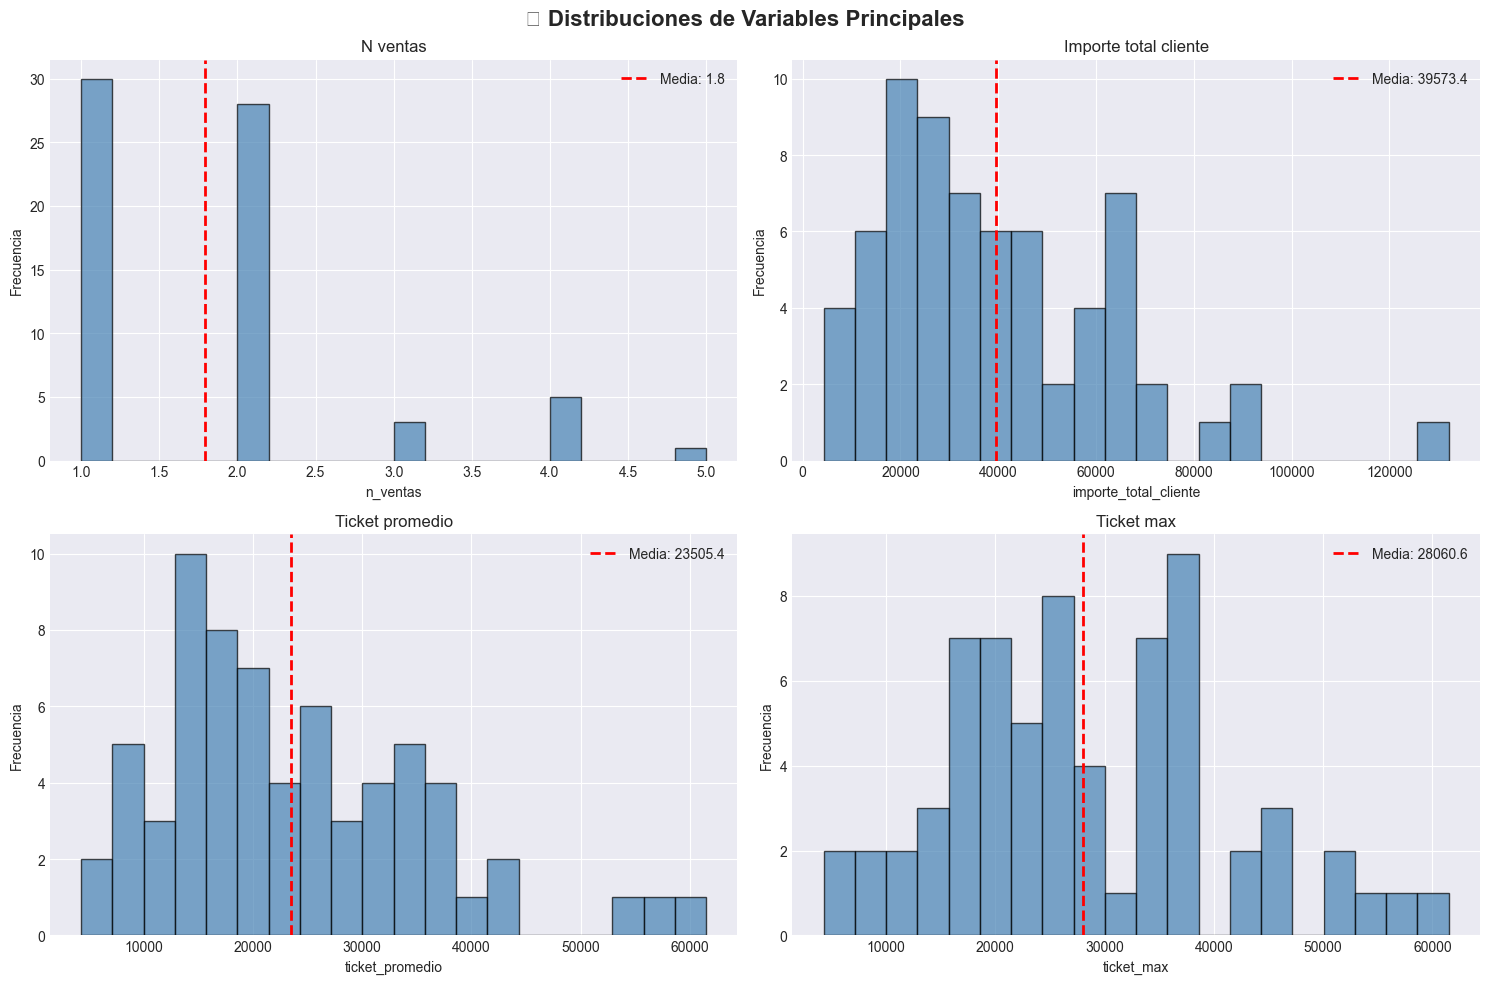

In [ ]:
# Visualización de distribuciones de variables principales
main_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
             'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
             'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

num_plots = min(4, len(main_cols))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Distribuciones de Variables Principales', fontsize=16, fontweight='bold')

for idx, col in enumerate(main_cols[:4]):
    if col in df.columns:
        ax = axes[idx // 2, idx % 2]
        ax.hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.1f}')
        ax.set_title(col.replace('_', ' ').capitalize())
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.legend()
    else:
        axes[idx // 2, idx % 2].set_visible(False)

plt.tight_layout()
plt.show()

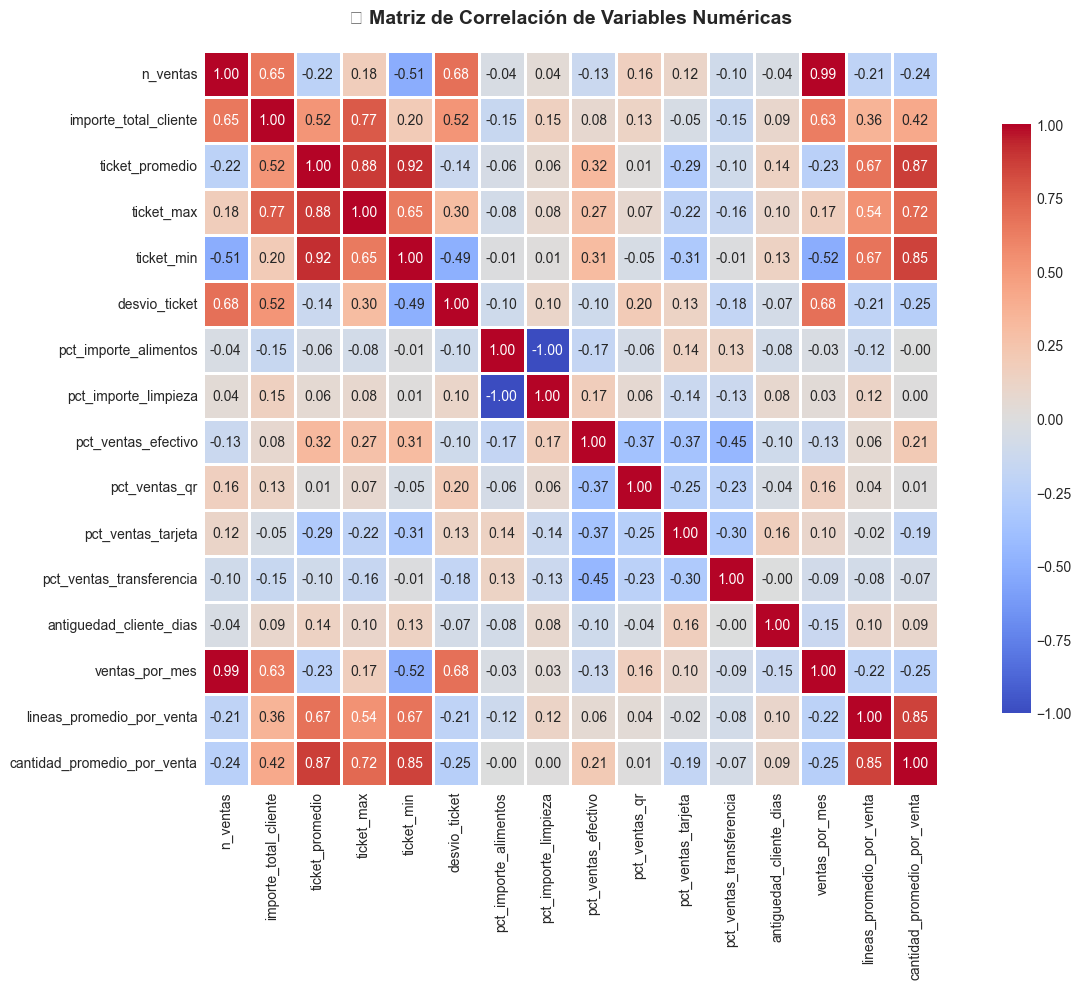


🔗 CORRELACIONES FUERTES (|r| > 0.7)


,Variable 1,Variable 2,Correlación
0,n_ventas,ventas_por_mes,0.992232
3,ticket_promedio,ticket_min,0.920638
2,ticket_promedio,ticket_max,0.882658
4,ticket_promedio,cantidad_promedio_por_venta,0.874312
8,lineas_promedio_por_venta,cantidad_promedio_por_venta,0.854210
6,ticket_min,cantidad_promedio_por_venta,0.852377
1,importe_total_cliente,ticket_max,0.767018
5,ticket_max,cantidad_promedio_por_venta,0.715839
7,pct_importe_alimentos,pct_importe_limpieza,-1.000000


In [8]:
# Matriz de correlación (solo variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id_cliente', errors='ignore')
plt.figure(figsize=(14, 10))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('🔥 Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n" + "="*80)
print("🔗 CORRELACIONES FUERTES (|r| > 0.7)")
print("="*80)
correlaciones_fuertes = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            correlaciones_fuertes.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if correlaciones_fuertes:
    df_corr = pd.DataFrame(correlaciones_fuertes).sort_values('Correlación', ascending=False)
    display(df_corr)
else:
    print("No se encontraron correlaciones > 0.7")

## 4️⃣ Preprocesamiento para Clustering

In [10]:
# Preparar datos para clustering (solo variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id_cliente', errors='ignore')
X_clustering = df[numeric_cols].copy()

print(f"\n✅ Dataset preparado:")
print(f"   - Filas: {X_clustering.shape[0]}")
print(f"   - Features: {X_clustering.shape[1]}")
print(f"   - Columnas: {list(X_clustering.columns)}")

# Verificar outliers con método IQR
print("\n" + "="*80)
print("🔍 DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*80)

outliers_report = []
for col in X_clustering.columns:
    Q1 = X_clustering[col].quantile(0.25)
    Q3 = X_clustering[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((X_clustering[col] < lower_bound) | (X_clustering[col] > upper_bound)).sum()
    if outliers > 0:
        outliers_report.append({
            'Variable': col,
            'Outliers': outliers,
            'Porcentaje': f"{(outliers/len(X_clustering)*100):.1f}%"
        })

if outliers_report:
    df_outliers = pd.DataFrame(outliers_report).sort_values('Outliers', ascending=False)
    display(df_outliers)
else:
    print("✅ No se detectaron outliers significativos")

# Escalar features (CRÍTICO para K-Means)
print("\n" + "="*80)
print("⚖️ ESCALADO DE FEATURES (StandardScaler)")
print("="*80)

scaler_clustering = StandardScaler()
X_scaled = scaler_clustering.fit_transform(X_clustering)

print(f"✅ Features escaladas: {X_scaled.shape}")
print(f"   Media: {X_scaled.mean():.6f}")
print(f"   Desv. Est.: {X_scaled.std():.6f}")

# Crear DataFrame escalado para visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clustering.columns, index=X_clustering.index)
print(f"\n📊 Primeras 3 filas escaladas:")
display(X_scaled_df.head(3))


✅ Dataset preparado:
   - Filas: 67
   - Features: 16
   - Columnas: ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket', 'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta', 'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

🔍 DETECCIÓN DE OUTLIERS (Método IQR)


,Variable,Outliers,Porcentaje
6,pct_importe_alimentos,9,13.4%
7,pct_importe_limpieza,9,13.4%
0,n_ventas,6,9.0%
8,ventas_por_mes,5,7.5%
4,ticket_min,2,3.0%
1,importe_total_cliente,1,1.5%
2,ticket_promedio,1,1.5%
3,ticket_max,1,1.5%
5,desvio_ticket,1,1.5%



⚖️ ESCALADO DE FEATURES (StandardScaler)
✅ Features escaladas: (67, 16)
   Media: 0.000000
   Desv. Est.: 1.000000

📊 Primeras 3 filas escaladas:


,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
0,0.222531,1.383271,1.056744,0.664750,1.231898,-0.816192,0.333204,-0.333204,-0.809091,-0.677204,0.878478,0.692393,1.567003,-0.015517,1.348251,1.014232
1,-0.842438,-0.733127,-0.112619,-0.470418,0.226324,-0.857677,0.333204,-0.333204,1.587770,-0.677204,-0.564121,-0.661405,1.532659,-0.881906,-1.756579,-1.000101
2,-0.842438,-0.263546,0.814629,0.417788,1.034549,-0.857677,0.333204,-0.333204,-0.809091,-0.677204,-0.564121,2.046190,1.498315,-0.881906,0.904704,1.517815


## 5️⃣ Determinación del Número Óptimo de Clusters (Método del Codo)

📐 DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS

Probando diferentes valores de K...
  K=2: Inertia=851.08, Silhouette=0.202
  K=2: Inertia=851.08, Silhouette=0.202
  K=3: Inertia=707.51, Silhouette=0.198
  K=3: Inertia=707.51, Silhouette=0.198
  K=4: Inertia=613.43, Silhouette=0.193
  K=5: Inertia=551.44, Silhouette=0.187
  K=4: Inertia=613.43, Silhouette=0.193
  K=5: Inertia=551.44, Silhouette=0.187
  K=6: Inertia=481.80, Silhouette=0.220
  K=6: Inertia=481.80, Silhouette=0.220
  K=7: Inertia=437.91, Silhouette=0.220
  K=7: Inertia=437.91, Silhouette=0.220
  K=8: Inertia=382.17, Silhouette=0.244
  K=8: Inertia=382.17, Silhouette=0.244
  K=9: Inertia=355.70, Silhouette=0.246
  K=9: Inertia=355.70, Silhouette=0.246
  K=10: Inertia=330.28, Silhouette=0.241
  K=10: Inertia=330.28, Silhouette=0.241


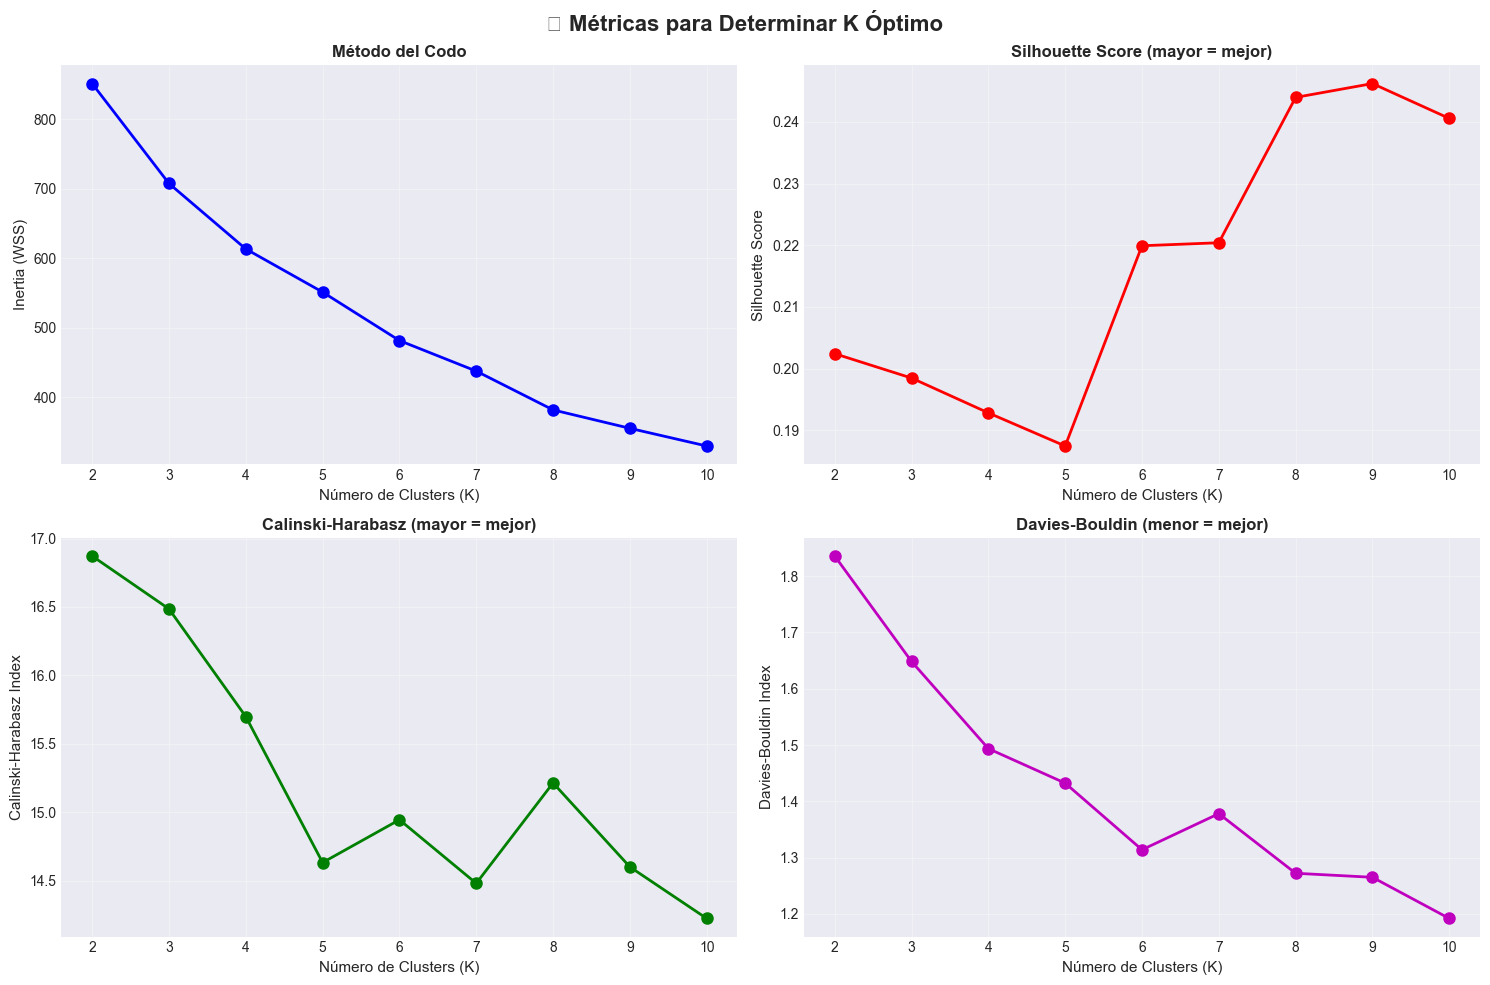


💡 RECOMENDACIÓN
✅ K óptimo según Silhouette: 9
✅ K óptimo según Calinski-Harabasz: 2
✅ K óptimo según Davies-Bouldin: 10

🎯 SELECCIÓN FINAL: K = 3 (segmentos VIP, Regular, Ocasional)


In [11]:
# Método del Codo + Silhouette Score
print("="*80)
print("📐 DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS")
print("="*80)

K_range = range(2, 11)
inertias = []
silhouettes = []
ch_scores = []
db_scores = []

print("\nProbando diferentes valores de K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.3f}")

# Visualizar métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Métricas para Determinar K Óptimo', fontsize=16, fontweight='bold')

# Método del Codo (Inertia)
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0, 0].set_ylabel('Inertia (WSS)', fontsize=11)
axes[0, 0].set_title('Método del Codo', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[0, 1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score (mayor = mejor)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz Index (mayor es mejor)
axes[1, 0].plot(K_range, ch_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz (mayor = mejor)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin Index (menor es mejor)
axes[1, 1].plot(K_range, db_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 1].set_title('Davies-Bouldin (menor = mejor)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recomendación
print("\n" + "="*80)
print("💡 RECOMENDACIÓN")
print("="*80)
best_k_silhouette = K_range[np.argmax(silhouettes)]
print(f"✅ K óptimo según Silhouette: {best_k_silhouette}")
print(f"✅ K óptimo según Calinski-Harabasz: {K_range[np.argmax(ch_scores)]}")
print(f"✅ K óptimo según Davies-Bouldin: {K_range[np.argmin(db_scores)]}")
print(f"\n🎯 SELECCIÓN FINAL: K = 3 (segmentos VIP, Regular, Ocasional)")

## 6️⃣ Entrenamiento del Modelo K-Means (K=3)

🎯 ENTRENAMIENTO MODELO K-MEANS

Entrenando modelo con K=3...
✅ Modelo entrenado exitosamente

📊 Información del modelo:
   - Clusters: 3
   - Iteraciones: 5
   - Inertia: 707.51

📊 DISTRIBUCIÓN DE CLUSTERS
cluster_label
Segmento A    19
Segmento B    19
Segmento C    29
Name: count, dtype: int64

Total: 67 clientes
✅ Modelo entrenado exitosamente

📊 Información del modelo:
   - Clusters: 3
   - Iteraciones: 5
   - Inertia: 707.51

📊 DISTRIBUCIÓN DE CLUSTERS
cluster_label
Segmento A    19
Segmento B    19
Segmento C    29
Name: count, dtype: int64

Total: 67 clientes


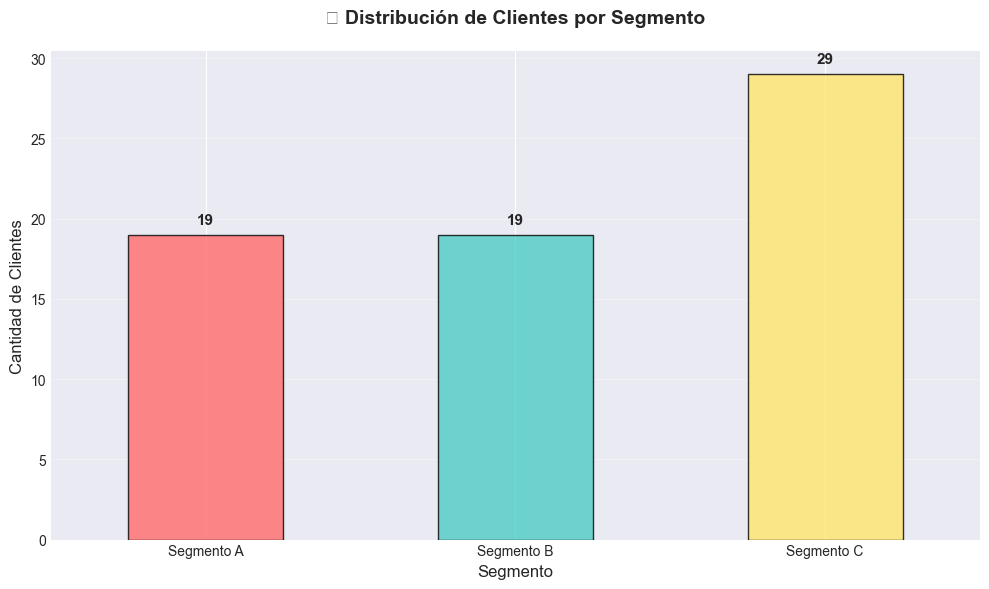

In [12]:
# Entrenar modelo K-Means con K=3
print("="*80)
print("🎯 ENTRENAMIENTO MODELO K-MEANS")
print("="*80)

K_OPTIMO = 3

kmeans_final = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=20,  # Múltiples inicializaciones
    max_iter=500,
    algorithm='lloyd'
)

print(f"\nEntrenando modelo con K={K_OPTIMO}...")
clusters = kmeans_final.fit_predict(X_scaled)

print("✅ Modelo entrenado exitosamente")
print(f"\n📊 Información del modelo:")
print(f"   - Clusters: {kmeans_final.n_clusters}")
print(f"   - Iteraciones: {kmeans_final.n_iter_}")
print(f"   - Inertia: {kmeans_final.inertia_:.2f}")

# Agregar clusters al dataset original
df['cluster'] = clusters
df['cluster_label'] = df['cluster'].map({
    0: 'Segmento A',
    1: 'Segmento B',
    2: 'Segmento C'
})

# Distribución de clusters
print("\n" + "="*80)
print("📊 DISTRIBUCIÓN DE CLUSTERS")
print("="*80)
cluster_counts = df['cluster_label'].value_counts().sort_index()
print(cluster_counts)
print(f"\nTotal: {len(df)} clientes")

# Visualizar distribución
plt.figure(figsize=(10, 6))
ax = cluster_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#FFE66D'], edgecolor='black', alpha=0.8)
plt.title('📊 Distribución de Clientes por Segmento', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(cluster_counts):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7️⃣ Evaluación del Modelo de Clustering

In [13]:
# Métricas de evaluación de clustering
print("="*80)
print("📈 MÉTRICAS DE EVALUACIÓN DEL CLUSTERING")
print("="*80)

silhouette = silhouette_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)

print(f"\n✅ Silhouette Score: {silhouette:.4f}")
print("   → Rango: [-1, 1]")
print("   → Interpretación: Valores cercanos a 1 indican clusters bien separados")
print(f"   → Estado: {'✅ Excelente' if silhouette > 0.5 else '⚠️ Moderado' if silhouette > 0.3 else '❌ Bajo'}")

print(f"\n✅ Calinski-Harabasz Index: {ch_score:.2f}")
print("   → Interpretación: Mayor valor indica mejor separación")
print(f"   → Estado: {'✅ Bueno' if ch_score > 100 else '⚠️ Moderado'}")

print(f"\n✅ Davies-Bouldin Index: {db_score:.4f}")
print("   → Rango: [0, ∞)")
print("   → Interpretación: Valores cercanos a 0 indican mejor clustering")
print(f"   → Estado: {'✅ Excelente' if db_score < 1 else '⚠️ Moderado' if db_score < 1.5 else '❌ Alto'}")

print(f"\n✅ Inertia (WSS): {kmeans_final.inertia_:.2f}")
print("   → Interpretación: Suma de distancias al cuadrado intra-cluster")

# Crear tabla resumen
metricas_df = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inertia'],
    'Valor': [f"{silhouette:.4f}", f"{ch_score:.2f}", f"{db_score:.4f}", f"{kmeans_final.inertia_:.2f}"],
    'Óptimo': ['Cercano a 1', 'Mayor', 'Cercano a 0', 'Menor']
})

print("\n" + "="*80)
print("📋 RESUMEN DE MÉTRICAS")
print("="*80)
display(metricas_df)

📈 MÉTRICAS DE EVALUACIÓN DEL CLUSTERING

✅ Silhouette Score: 0.1985
   → Rango: [-1, 1]
   → Interpretación: Valores cercanos a 1 indican clusters bien separados
   → Estado: ❌ Bajo

✅ Calinski-Harabasz Index: 16.49
   → Interpretación: Mayor valor indica mejor separación
   → Estado: ⚠️ Moderado

✅ Davies-Bouldin Index: 1.6485
   → Rango: [0, ∞)
   → Interpretación: Valores cercanos a 0 indican mejor clustering
   → Estado: ❌ Alto

✅ Inertia (WSS): 707.51
   → Interpretación: Suma de distancias al cuadrado intra-cluster

📋 RESUMEN DE MÉTRICAS


,Métrica,Valor,Óptimo
0,Silhouette Score,0.1985,Cercano a 1
1,Calinski-Harabasz,16.49,Mayor
2,Davies-Bouldin,1.6485,Cercano a 0
3,Inertia,707.51,Menor


## 8️⃣ Visualización de Clusters con PCA

Reduciremos las dimensiones a 2D para visualizar los clusters en un plano.

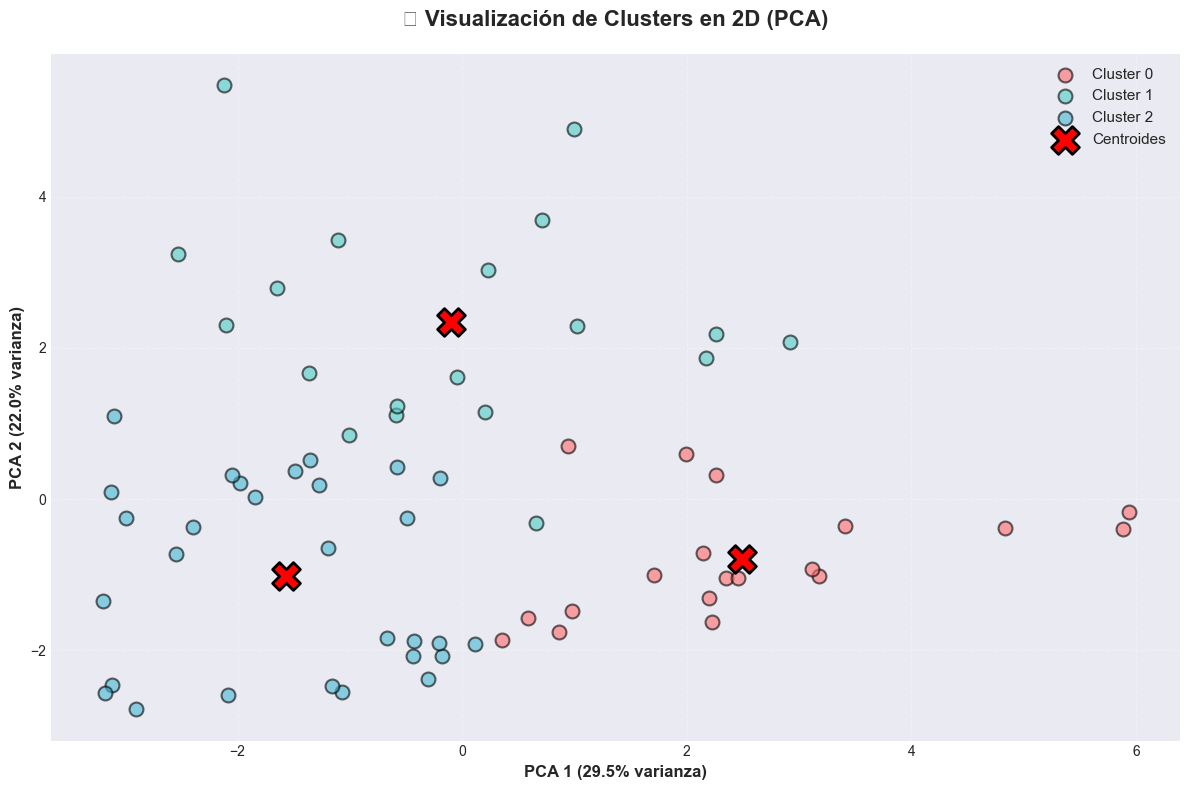


📊 Varianza explicada por PCA:
   - PCA1: 29.50%
   - PCA2: 22.01%
   - Total: 51.51%


In [14]:
# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Agregar componentes PCA al dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Visualización de clusters en 2D
fig, ax = plt.subplots(figsize=(12, 8))

colores = ['#FF6B6B', '#4ECDC4', '#45B7D1']
nombres_clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = clusters == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colores[i], label=nombres_clusters[i],
               s=100, alpha=0.6, edgecolors='black', linewidths=1.5)

# Agregar centroides
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
           c='red', marker='X', s=400, edgecolors='black', linewidths=2,
           label='Centroides', zorder=5)

ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12, fontweight='bold')
ax.set_title('🎯 Visualización de Clusters en 2D (PCA)', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n📊 Varianza explicada por PCA:")
print(f"   - PCA1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   - PCA2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   - Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 9️⃣ Perfiles de Segmentos

Analizaremos las características promedio de cada cluster para crear perfiles de clientes.

In [15]:
# Calcular perfiles de cada cluster con columnas reales
perfil_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
               'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
               'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

perfiles = df.groupby('cluster')[perfil_cols].agg(['mean', 'median']).round(2)

print("="*80)
print("📊 PERFILES DE SEGMENTOS - ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
display(perfiles)

# Crear perfiles simples solo con medias
perfiles_simple = df.groupby('cluster')[perfil_cols].mean().round(2)

print("\n" + "="*80)
print("📋 PERFILES SIMPLIFICADOS (MEDIAS)")
print("="*80)
display(perfiles_simple)

# Tamaños de cada cluster
tamanos = df['cluster'].value_counts().sort_index()
print("\n" + "="*80)
print("👥 TAMAÑO DE CADA SEGMENTO")
print("="*80)
for cluster, count in tamanos.items():
    porcentaje = (count / len(df)) * 100
    print(f"   Cluster {cluster}: {count} clientes ({porcentaje:.1f}%)")

📊 PERFILES DE SEGMENTOS - ESTADÍSTICAS DESCRIPTIVAS


n_ventas        importe_total_cliente          ticket_promedio  \
            mean median                  mean   median            mean   
cluster                                                                  
0           1.16    1.0              41046.58  36639.0        35932.47   
1           2.74    2.0              63497.11  64716.0        24468.35   
2           1.59    2.0              22934.03  21839.0        14732.72   

                 ticket_max          ticket_min           ...  \
          median       mean   median       mean   median  ...   
cluster                                                   ...   
0        35240.0   36302.16  35240.0   35562.79  35240.0  ...   
1        24433.5   35499.42  35856.0   13782.00  11832.0  ...   
2        14954.5   17787.34  16531.0   11624.76  11184.0  ...   

        pct_ventas_transferencia        antiguedad_cliente_dias         \
                            mean median                    mean median   
cluster                                                                  
0                          18.42    0.0                  495.68  508.0   
1                          13.33    0.0                  500.05  497.0   
2                          35.63    0.0                  499.03  502.0   

        ventas_por_mes        lineas_promedio_por_venta         \
                  mean median                      mean median   
cluster                                                          
0                 0.07   0.06                      3.97    4.0   
1                 0.17   0.13                      3.00    3.0   
2                 0.10   0.12                      2.32    2.0   

        cantidad_promedio_por_venta         
                               mean median  
cluster                                     
0                             13.34   13.0  
1                              8.61    8.0  
2                              6.34    6.0  

[3 rows x 32 columns]


📋 PERFILES SIMPLIFICADOS (MEDIAS)


,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
cluster,,,,,,,,,,,,,,,,
0,1.16,41046.58,35932.47,36302.16,35562.79,522.81,100.00,0.00,60.53,18.42,2.63,18.42,495.68,0.07,3.97,13.34
1,2.74,63497.11,24468.35,35499.42,13782.00,12465.64,90.22,9.78,42.72,27.63,16.32,13.33,500.05,0.17,3.00,8.61
2,1.59,22934.03,14732.72,17787.34,11624.76,4257.37,100.00,0.00,10.34,21.26,32.76,35.63,499.03,0.10,2.32,6.34



👥 TAMAÑO DE CADA SEGMENTO
   Cluster 0: 19 clientes (28.4%)
   Cluster 1: 19 clientes (28.4%)
   Cluster 2: 29 clientes (43.3%)


## 🔟 Heatmap de Características por Cluster

Visualización de las diferencias entre clusters mediante un mapa de calor.

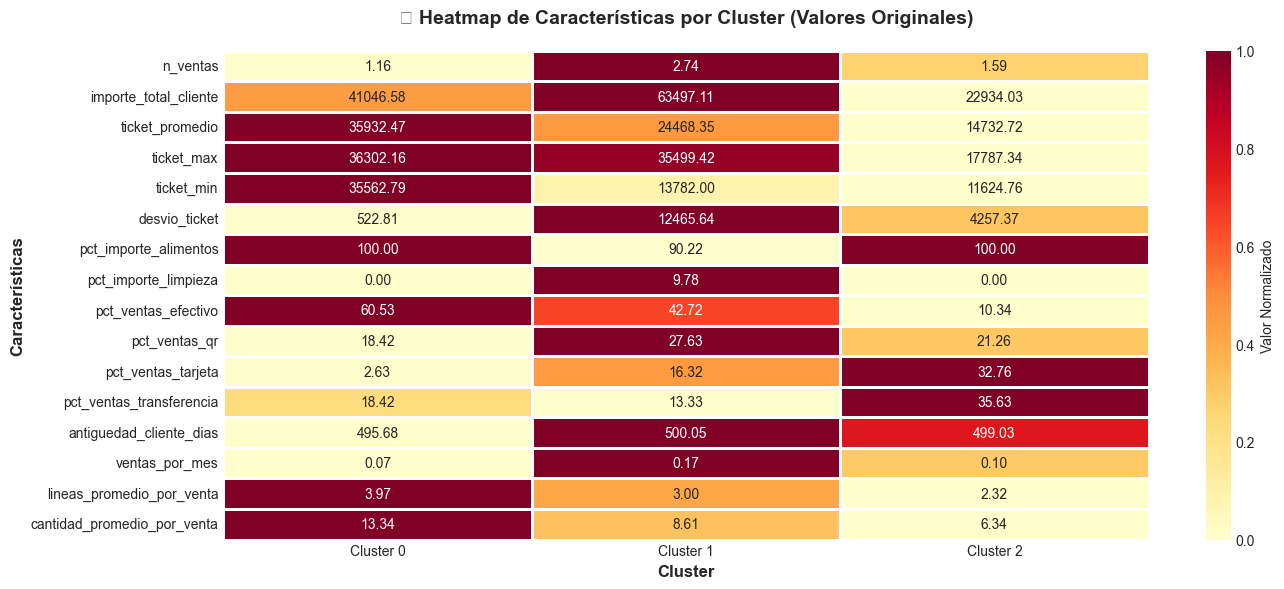

In [16]:
# Heatmap de características promedio por cluster
fig, ax = plt.subplots(figsize=(14, 6))

# Normalizar valores para mejor visualización (min-max scaling)
perfiles_norm = perfiles_simple.copy()
for col in perfiles_norm.columns:
    min_val = perfiles_norm[col].min()
    max_val = perfiles_norm[col].max()
    if max_val - min_val > 0:
        perfiles_norm[col] = (perfiles_norm[col] - min_val) / (max_val - min_val)

sns.heatmap(perfiles_norm.T, annot=perfiles_simple.T, fmt='.2f', 
            cmap='YlOrRd', cbar_kws={'label': 'Valor Normalizado'},
            linewidths=2, linecolor='white', ax=ax)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Características', fontsize=12, fontweight='bold')
ax.set_title('🔥 Heatmap de Características por Cluster (Valores Originales)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'], rotation=0)
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Comparación de Variables Clave por Cluster (Boxplots)

Visualización de la distribución de las variables más importantes en cada cluster.

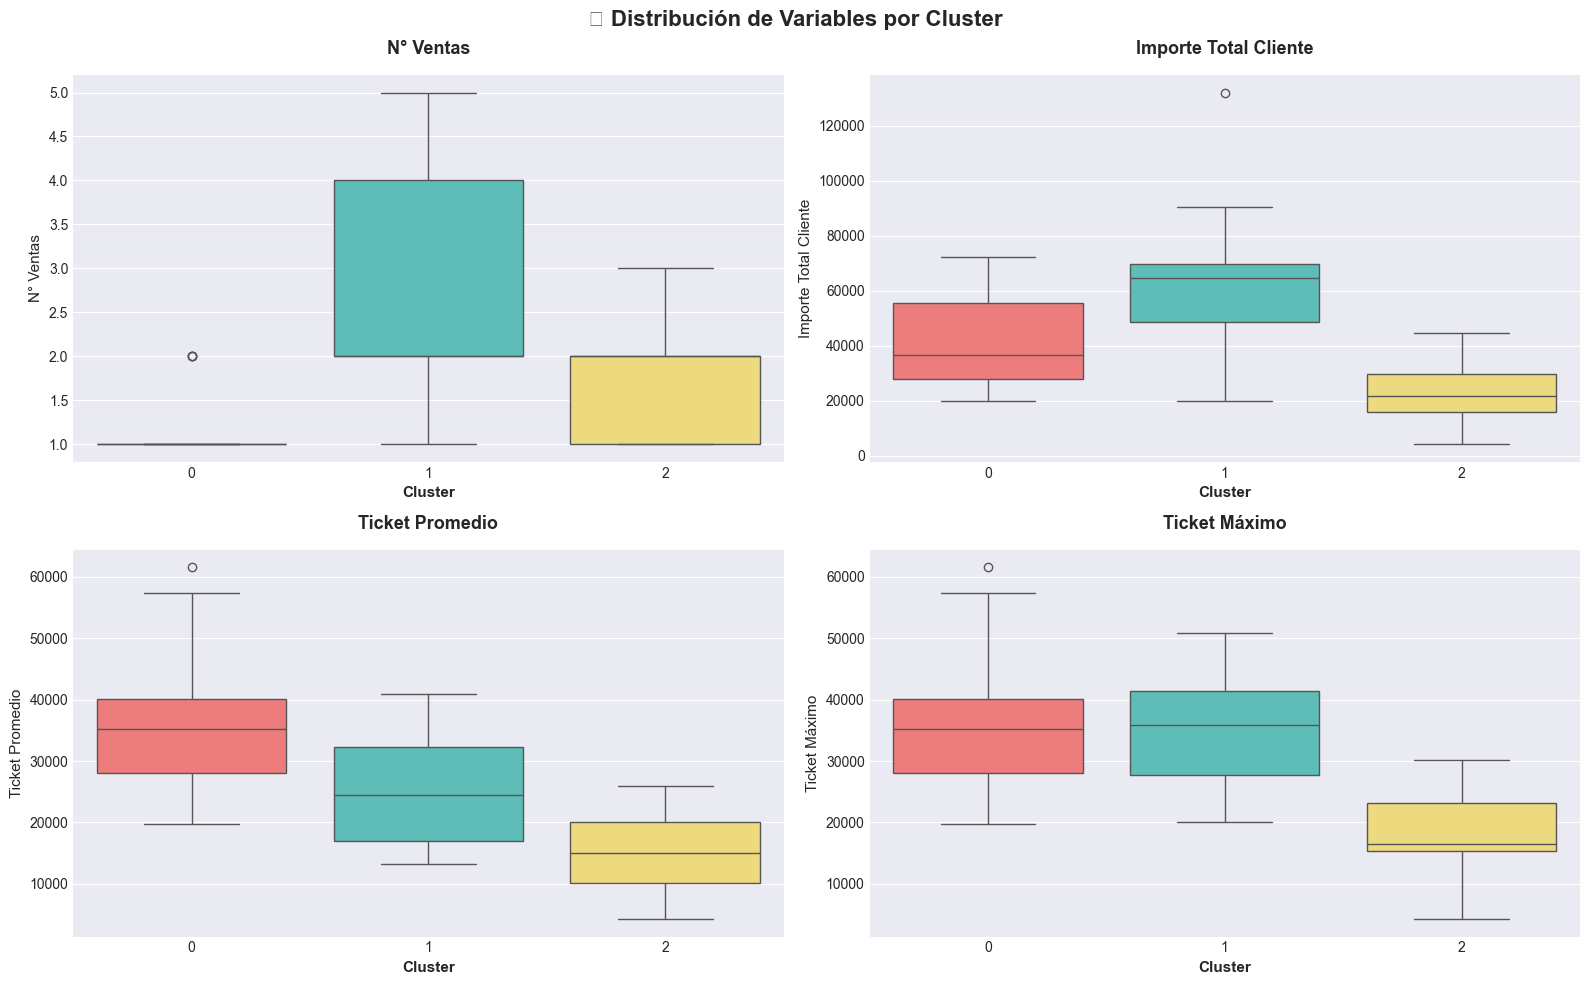

In [ ]:
# Boxplots de variables principales por cluster
variables = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max']
titulos = ['N° Ventas', 'Importe Total Cliente', 'Ticket Promedio', 'Ticket Máximo']
colores_palette = ['#FF6B6B', '#4ECDC4', '#FFE66D']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📦 Distribución de Variables por Cluster', fontsize=16, fontweight='bold')

for idx, (var, titulo) in enumerate(zip(variables, titulos)):
    ax = axes[idx // 2, idx % 2]
    if var in df.columns:
        sns.boxplot(data=df, x='cluster', y=var, palette=colores_palette, ax=ax)
        ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
        ax.set_ylabel(titulo, fontsize=11)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()


## 1️⃣2️⃣ Interpretación de Segmentos

Interpretación del negocio basada en los perfiles identificados.

In [20]:
# Ejemplo de interpretación de un cliente (usando variables reales)
cliente_id = 1  # Cambia el ID según corresponda
datos = df[df['id_cliente'] == cliente_id].squeeze()

print(f"{'='*80}")
print(f"🧑‍💼 Perfil del Cliente ID: {cliente_id}")
print(f"Ciudad: {datos['ciudad']}")
print(f"Segmento: {datos['cluster_label']}")
print(f"{'='*80}")

print(f"\n🔹 Características principales:")
print(f"   • N° Ventas: {datos['n_ventas']}")
print(f"   • Importe Total Cliente: ${datos['importe_total_cliente']:.2f}")
print(f"   • Ticket Promedio: ${datos['ticket_promedio']:.2f}")
print(f"   • Ticket Máximo: ${datos['ticket_max']:.2f}")
print(f"   • Ticket Mínimo: ${datos['ticket_min']:.2f}")
print(f"   • Desvío Ticket: ${datos['desvio_ticket']:.2f}")
print(f"   • % Importe Alimentos: {datos['pct_importe_alimentos']:.1f}%")
print(f"   • % Importe Limpieza: {datos['pct_importe_limpieza']:.1f}%")
print(f"   • % Ventas Efectivo: {datos['pct_ventas_efectivo']:.1f}%")
print(f"   • % Ventas QR: {datos['pct_ventas_qr']:.1f}%")
print(f"   • % Ventas Tarjeta: {datos['pct_ventas_tarjeta']:.1f}%")
print(f"   • % Ventas Transferencia: {datos['pct_ventas_transferencia']:.1f}%")
print(f"   • Antigüedad Cliente (días): {datos['antiguedad_cliente_dias']}")
print(f"   • Ventas por Mes: {datos['ventas_por_mes']:.2f}")
print(f"   • Líneas Promedio por Venta: {datos['lineas_promedio_por_venta']:.2f}")
print(f"   • Cantidad Promedio por Venta: {datos['cantidad_promedio_por_venta']:.2f}")

🧑‍💼 Perfil del Cliente ID: 1
Ciudad: carlos paz
Segmento: Segmento A

🔹 Características principales:
   • N° Ventas: 2
   • Importe Total Cliente: $72448.00
   • Ticket Promedio: $36224.00
   • Ticket Máximo: $36413.00
   • Ticket Mínimo: $36035.00
   • Desvío Ticket: $267.29
   • % Importe Alimentos: 100.0%
   • % Importe Limpieza: 0.0%
   • % Ventas Efectivo: 0.0%
   • % Ventas QR: 0.0%
   • % Ventas Tarjeta: 50.0%
   • % Ventas Transferencia: 50.0%
   • Antigüedad Cliente (días): 544
   • Ventas por Mes: 0.11
   • Líneas Promedio por Venta: 4.50
   • Cantidad Promedio por Venta: 13.00


## 1️⃣3️⃣ Exportar Modelo y Resultados

Guardar el modelo entrenado, el scaler y los perfiles de segmentos para uso futuro.

In [27]:
# Crear carpeta para modelos si no existe
import os
os.makedirs('modelos', exist_ok=True)

# Guardar modelo de clustering
joblib.dump(kmeans_final, 'modelos/kmeans_segmentacion.pkl')
print("✅ Modelo K-Means guardado: modelos/kmeans_segmentacion.pkl")

# Guardar scaler
joblib.dump(scaler_clustering, 'modelos/scaler_clustering.pkl')
print("✅ Scaler guardado: modelos/scaler_clustering.pkl")

# Guardar PCA
joblib.dump(pca, 'modelos/pca_clustering.pkl')
print("✅ PCA guardado: modelos/pca_clustering.pkl")

# Exportar perfiles de segmentos
perfiles_simple.to_csv('modelos/perfiles_segmentos.csv')
print("✅ Perfiles exportados: modelos/perfiles_segmentos.csv")

# Exportar dataset con clusters asignados
df_export = df.copy()
df_export.to_csv('modelos/clientes_con_clusters.csv', index=False)
print("✅ Dataset con clusters guardado: modelos/clientes_con_clusters.csv")

print("\n" + "="*80)
print("🎉 MODELO DE SEGMENTACIÓN COMPLETADO Y EXPORTADO")
print("="*80)

✅ Modelo K-Means guardado: modelos/kmeans_segmentacion.pkl
✅ Scaler guardado: modelos/scaler_clustering.pkl
✅ PCA guardado: modelos/pca_clustering.pkl
✅ Perfiles exportados: modelos/perfiles_segmentos.csv
✅ Dataset con clusters guardado: modelos/clientes_con_clusters.csv

🎉 MODELO DE SEGMENTACIÓN COMPLETADO Y EXPORTADO


---

# 🔮 PARTE 2: PREDICCIÓN DE CHURN (Clasificación)

**Objetivo:** Predecir qué clientes tienen mayor probabilidad de abandonar el negocio (churn) basándonos en su comportamiento de compra.

## 1️⃣4️⃣ Definición de Target (Churn)

Definir la variable objetivo: un cliente se considera "churned" si su recencia es mayor a 60 días.

**ℹ️ NOTA METODOLÓGICA - Data Leakage (qué haría mal un modelo):**  
En muchos ejemplos educativos se usa `recency` tanto para definir el target como feature predictora, lo que sí constituiría **fuga de información (data leakage)** y tendería a inflar las métricas.

En este proyecto:

- Definimos `churn` a partir de `recency` (p.ej. recency > 60 días).
- **Excluimos `recency` de las features del modelo** (`X_churn`) para evitar fuga de información.
- En un entorno productivo ideal, además se recomendaría definir `churn` con una ventana futura (ej.: “no compra en los próximos N días” usando solo información pasada).

🎯 DEFINICIÓN DE CHURN

✅ Umbral de churn: 60 días de recencia
   - Churn = 1: Cliente inactivo (recency > 60 días)
   - Churn = 0: Cliente activo (recency ≤ 60 días)

ℹ️ NOTA TÉCNICA SOBRE DATA LEAKAGE
La variable 'churn' se define a partir de 'recency' (p.ej. recency > 60 días).
Si además usáramos 'recency' como feature del modelo, habría FUGA DE INFORMACIÓN
(data leakage) y las métricas se verían artificialmente infladas.

En este modelo de churn:
   • 'recency' se usa SOLO para definir el target 'churn'.
   • En las features EXCLUIMOS 'recency'.

📊 Distribución de Churn:
   - Clientes Activos (0): 32 (47.8%)
   - Clientes en Riesgo (1): 35 (52.2%)


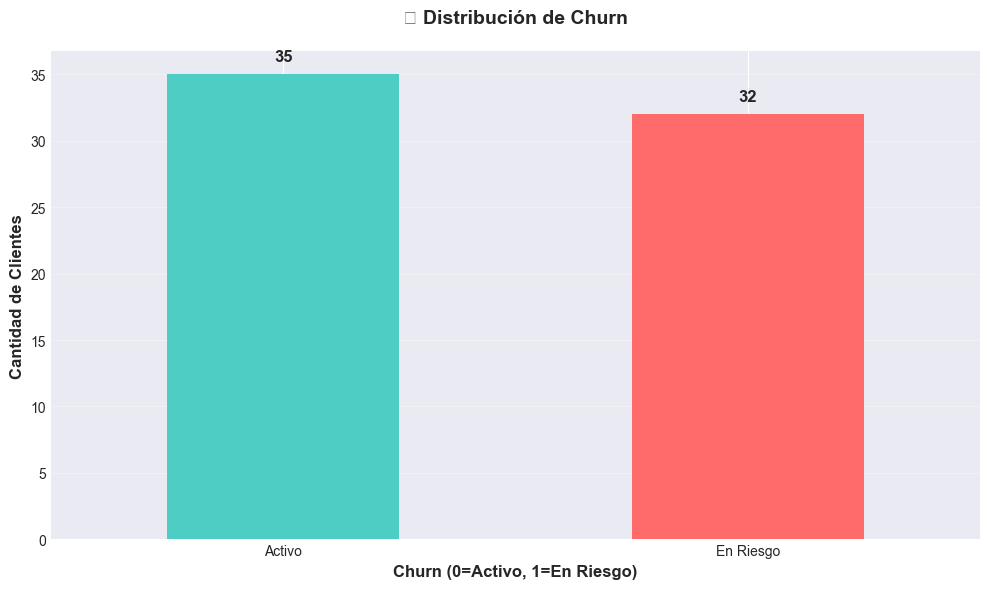

In [36]:
# ============================================================
# BLOQUE 1 – Construcción de df_churn + recency + churn
# ============================================================

# 1) Dataset transaccional (para calcular recency)
df_tx = pd.read_csv('db/Base_Final_Aurelion.csv')
df_tx['fecha'] = pd.to_datetime(df_tx['fecha'])

# Tomamos como fecha de referencia la última fecha de compra registrada
fecha_referencia = df_tx['fecha'].max()

# Última compra por cliente
recency_df = (
    df_tx
    .groupby('id_cliente')['fecha']
    .max()
    .reset_index()
    .rename(columns={'fecha': 'ultima_compra'})
)

# Recency = días desde la última compra hasta la fecha de referencia
recency_df['recency'] = (fecha_referencia - recency_df['ultima_compra']).dt.days

# 2) Dataset a nivel cliente (base para ML)
df_churn = pd.read_csv('db/base_final_ML_clientes.csv')

# Unir recency por id_cliente
df_churn = df_churn.merge(
    recency_df[['id_cliente', 'recency']],
    on='id_cliente',
    how='left'
)

# Definir umbral de churn: recencia > 60 días
umbral_churn = 60
df_churn['churn'] = (df_churn['recency'] > umbral_churn).astype(int)

print("="*80)
print("🎯 DEFINICIÓN DE CHURN")
print("="*80)
print(f"\n✅ Umbral de churn: {umbral_churn} días de recencia")
print(f"   - Churn = 1: Cliente inactivo (recency > {umbral_churn} días)")
print(f"   - Churn = 0: Cliente activo (recency ≤ {umbral_churn} días)")

print("\n" + "="*80)
print("ℹ️ NOTA TÉCNICA SOBRE DATA LEAKAGE")
print("="*80)
print("La variable 'churn' se define a partir de 'recency' (p.ej. recency > 60 días).")
print("Si además usáramos 'recency' como feature del modelo, habría FUGA DE INFORMACIÓN")
print("(data leakage) y las métricas se verían artificialmente infladas.")
print("\nEn este modelo de churn:")
print("   • 'recency' se usa SOLO para definir el target 'churn'.")
print("   • En las features EXCLUIMOS 'recency'.")
print("="*80)

# Distribución de churn
churn_dist = df_churn['churn'].value_counts()
print(f"\n📊 Distribución de Churn:")
print(f"   - Clientes Activos (0): {churn_dist[0]} ({churn_dist[0]/len(df_churn)*100:.1f}%)")
print(f"   - Clientes en Riesgo (1): {churn_dist[1]} ({churn_dist[1]/len(df_churn)*100:.1f}%)")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
churn_dist.plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=ax)
ax.set_title('📊 Distribución de Churn', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Churn (0=Activo, 1=En Riesgo)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(churn_dist):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Verificar balance de clases
if churn_dist.min() / churn_dist.max() < 0.3:
    print("\n⚠️ ADVERTENCIA: Clases desbalanceadas. Se recomienda usar SMOTE o class_weight='balanced'")



## 1️⃣5️⃣ Preparación de Datos para Clasificación

Preparar las features y aplicar train-test split estratificado.
En este paso se construye la matriz de features excluyendo `id_cliente`, `churn` y `recency` para evitar data leakage.

In [37]:
# ============================================================
# BLOQUE 2 – Preparación de datos (X, y, split, escalado)
# ============================================================

# 1) Excluimos 'id_cliente', 'churn' y 'recency'
features_candidatas = df_churn.drop(['id_cliente', 'churn', 'recency'], axis=1)

# 2) Nos quedamos SOLO con columnas numéricas (evitamos strings como 'ciudad')
feature_cols = features_candidatas.select_dtypes(include=['number']).columns.tolist()

print("="*80)
print("📋 SELECCIÓN DE FEATURES NUMÉRICAS")
print("="*80)
print(f"\n✅ Total de columnas candidatas: {features_candidatas.shape[1]}")
print(f"✅ Columnas numéricas seleccionadas para el modelo de churn: {len(feature_cols)}")
print("\n📌 Features utilizadas:")
for col in feature_cols:
    print(f"   • {col}")

# Matriz final de features y target
X_churn = df_churn[feature_cols]
y_churn = df_churn['churn']

print("\n" + "="*80)
print("📋 PREPARACIÓN DE DATOS")
print("="*80)
print(f"\n✅ Features seleccionadas: {X_churn.shape[1]}")
print(f"✅ Total de observaciones: {X_churn.shape[0]}")

# Split estratificado (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print(f"\n✅ Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df_churn)*100:.1f}%)")
print(f"   - Activos: {sum(y_train==0)} | En Riesgo: {sum(y_train==1)}")
print(f"✅ Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df_churn)*100:.1f}%)")
print(f"   - Activos: {sum(y_test==0)} | En Riesgo: {sum(y_test==1)}")

# Escalar features
scaler_churn = StandardScaler()
X_train_scaled = scaler_churn.fit_transform(X_train)
X_test_scaled = scaler_churn.transform(X_test)

print(f"\n✅ Features escaladas con StandardScaler")


📋 SELECCIÓN DE FEATURES NUMÉRICAS

✅ Total de columnas candidatas: 17
✅ Columnas numéricas seleccionadas para el modelo de churn: 16

📌 Features utilizadas:
   • n_ventas
   • importe_total_cliente
   • ticket_promedio
   • ticket_max
   • ticket_min
   • desvio_ticket
   • pct_importe_alimentos
   • pct_importe_limpieza
   • pct_ventas_efectivo
   • pct_ventas_qr
   • pct_ventas_tarjeta
   • pct_ventas_transferencia
   • antiguedad_cliente_dias
   • ventas_por_mes
   • lineas_promedio_por_venta
   • cantidad_promedio_por_venta

📋 PREPARACIÓN DE DATOS

✅ Features seleccionadas: 16
✅ Total de observaciones: 67

✅ Train set: 53 muestras (79.1%)
   - Activos: 25 | En Riesgo: 28
✅ Test set: 14 muestras (20.9%)
   - Activos: 7 | En Riesgo: 7

✅ Features escaladas con StandardScaler


## 1️⃣6️⃣ Balanceo de Clases con SMOTE

Aplicar SMOTE para balancear clases en el conjunto de entrenamiento.

⚖️ BALANCEO DE CLASES CON SMOTE

📊 ANTES de SMOTE:
   - Clase 0 (Activo): 25
   - Clase 1 (En Riesgo): 28
   - Ratio: 1.12

📊 DESPUÉS de SMOTE:
   - Clase 0 (Activo): 28
   - Clase 1 (En Riesgo): 28
   - Ratio: 1.00

✅ Se generaron 0 muestras sintéticas de la clase minoritaria


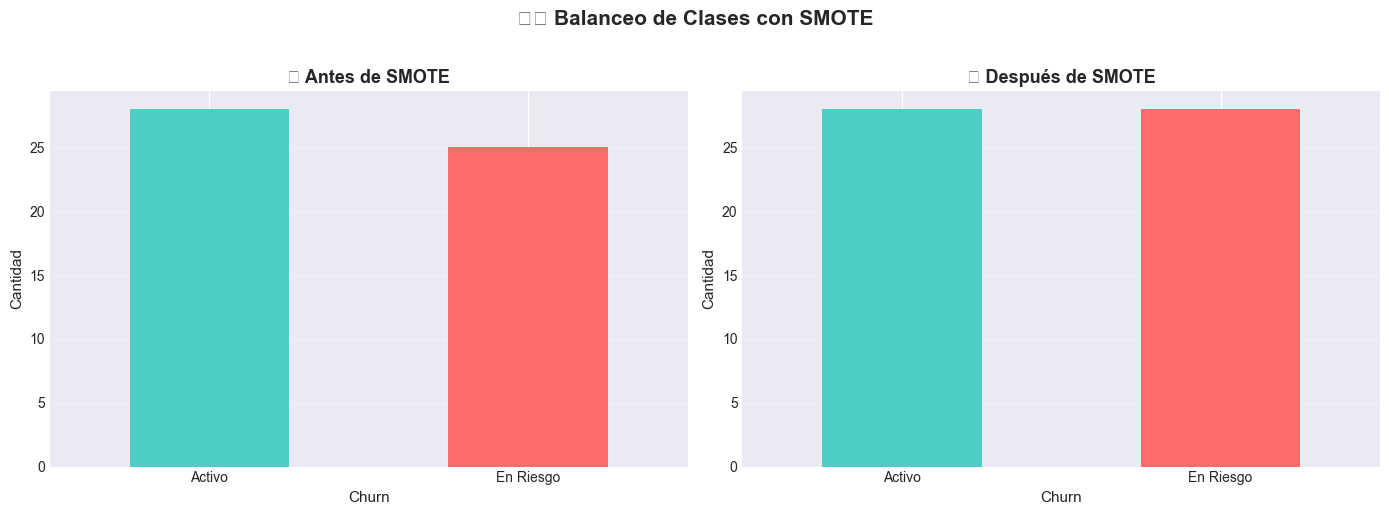

In [38]:
# ============================================================
# BLOQUE 3 – Balanceo de clases con SMOTE
# ============================================================

# Aplicar SMOTE para balancear clases
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("="*80)
print("⚖️ BALANCEO DE CLASES CON SMOTE")
print("="*80)

print(f"\n📊 ANTES de SMOTE:")
print(f"   - Clase 0 (Activo): {sum(y_train==0)}")
print(f"   - Clase 1 (En Riesgo): {sum(y_train==1)}")
print(f"   - Ratio: {sum(y_train==1)/sum(y_train==0):.2f}")

print(f"\n📊 DESPUÉS de SMOTE:")
print(f"   - Clase 0 (Activo): {sum(y_train_smote==0)}")
print(f"   - Clase 1 (En Riesgo): {sum(y_train_smote==1)}")
print(f"   - Ratio: {sum(y_train_smote==1)/sum(y_train_smote==0):.2f}")

print(f"\n✅ Se generaron {sum(y_train_smote==1) - sum(y_train==1)} muestras sintéticas de la clase minoritaria")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de SMOTE
pd.Series(y_train).value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=axes[0])
axes[0].set_title('📊 Antes de SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=11)
axes[0].set_ylabel('Cantidad', fontsize=11)
axes[0].set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Después de SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=axes[1])
axes[1].set_title('📊 Después de SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn', fontsize=11)
axes[1].set_ylabel('Cantidad', fontsize=11)
axes[1].set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('⚖️ Balanceo de Clases con SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 1️⃣7️⃣ Entrenamiento del Modelo de Clasificación (Random Forest)

Entrenar un Random Forest Classifier para predecir churn.

In [39]:
# ============================================================
# BLOQUE 4 – Entrenamiento de Random Forest Classifier
# ============================================================

print("="*80)
print("🌲 ENTRENAMIENTO DE RANDOM FOREST CLASSIFIER")
print("="*80)

rf_churn = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entrenando modelo...")
rf_churn.fit(X_train_smote, y_train_smote)
print("✅ Modelo entrenado exitosamente")

# Predicciones en train y test
y_train_pred = rf_churn.predict(X_train_scaled)
y_test_pred = rf_churn.predict(X_test_scaled)

# Probabilidades (para ROC-AUC)
y_train_proba = rf_churn.predict_proba(X_train_scaled)[:, 1]
y_test_proba = rf_churn.predict_proba(X_test_scaled)[:, 1]

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n📊 ACCURACY:")
print(f"   - Train: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   - Test: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Diferencia (overfitting check)
diff = train_acc - test_acc
if diff > 0.1:
    print(f"   ⚠️ Posible overfitting (diferencia: {diff:.4f})")
elif diff < 0:
    print(f"   ⚠️ Modelo bajo ajuste (diferencia: {diff:.4f})")
else:
    print(f"   ✅ Buen balance train/test (diferencia: {diff:.4f})")


🌲 ENTRENAMIENTO DE RANDOM FOREST CLASSIFIER

⏳ Entrenando modelo...
✅ Modelo entrenado exitosamente
✅ Modelo entrenado exitosamente

📊 ACCURACY:
   - Train: 0.9811 (98.11%)
   - Test: 0.5714 (57.14%)
   ⚠️ Posible overfitting (diferencia: 0.4097)

📊 ACCURACY:
   - Train: 0.9811 (98.11%)
   - Test: 0.5714 (57.14%)
   ⚠️ Posible overfitting (diferencia: 0.4097)


## 1️⃣8️⃣ Evaluación del Modelo de Clasificación

Métricas detalladas: Confusion Matrix, Classification Report, ROC-AUC.

📊 EVALUACIÓN DEL MODELO - CONJUNTO DE TEST


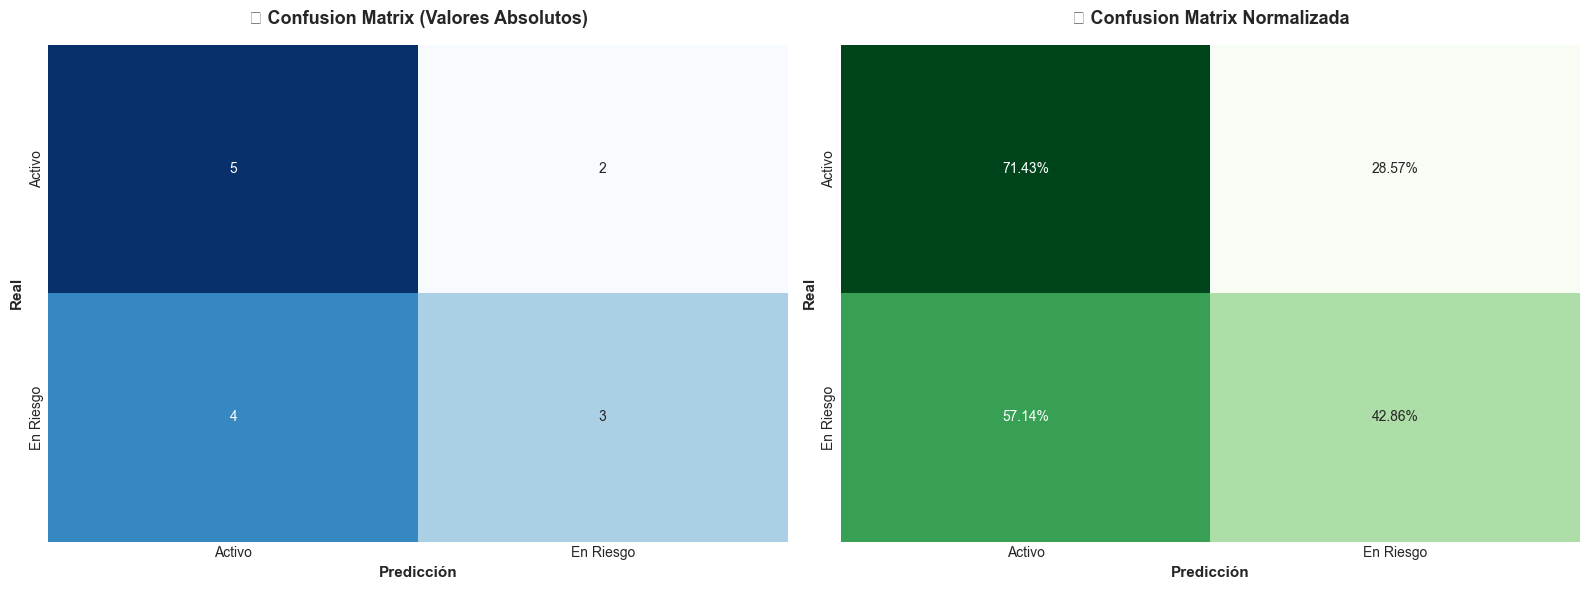


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Activo       0.56      0.71      0.62         7
   En Riesgo       0.60      0.43      0.50         7

    accuracy                           0.57        14
   macro avg       0.58      0.57      0.56        14
weighted avg       0.58      0.57      0.56        14


✅ ROC-AUC Score: 0.5714
   ⚠️ Poder predictivo moderado


In [40]:
# ============================================================
# BLOQUE 5 – Evaluación: matriz de confusión, report, ROC-AUC
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

print("="*80)
print("📊 EVALUACIÓN DEL MODELO - CONJUNTO DE TEST")
print("="*80)

# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión (valores absolutos)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Activo', 'En Riesgo'], yticklabels=['Activo', 'En Riesgo'])
axes[0].set_title('🔢 Confusion Matrix (Valores Absolutos)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')

# Matriz de confusión normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Activo', 'En Riesgo'], yticklabels=['Activo', 'En Riesgo'])
axes[1].set_title('📊 Confusion Matrix Normalizada', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_test_pred, target_names=['Activo', 'En Riesgo']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\n✅ ROC-AUC Score: {roc_auc:.4f}")

if roc_auc > 0.9:
    print("   🎉 Excelente poder predictivo")
elif roc_auc > 0.8:
    print("   ✅ Muy buen poder predictivo")
elif roc_auc > 0.7:
    print("   👍 Buen poder predictivo")
else:
    print("   ⚠️ Poder predictivo moderado")


## 1️⃣9️⃣ Curva ROC

Visualización de la curva ROC para evaluar el rendimiento del clasificador.

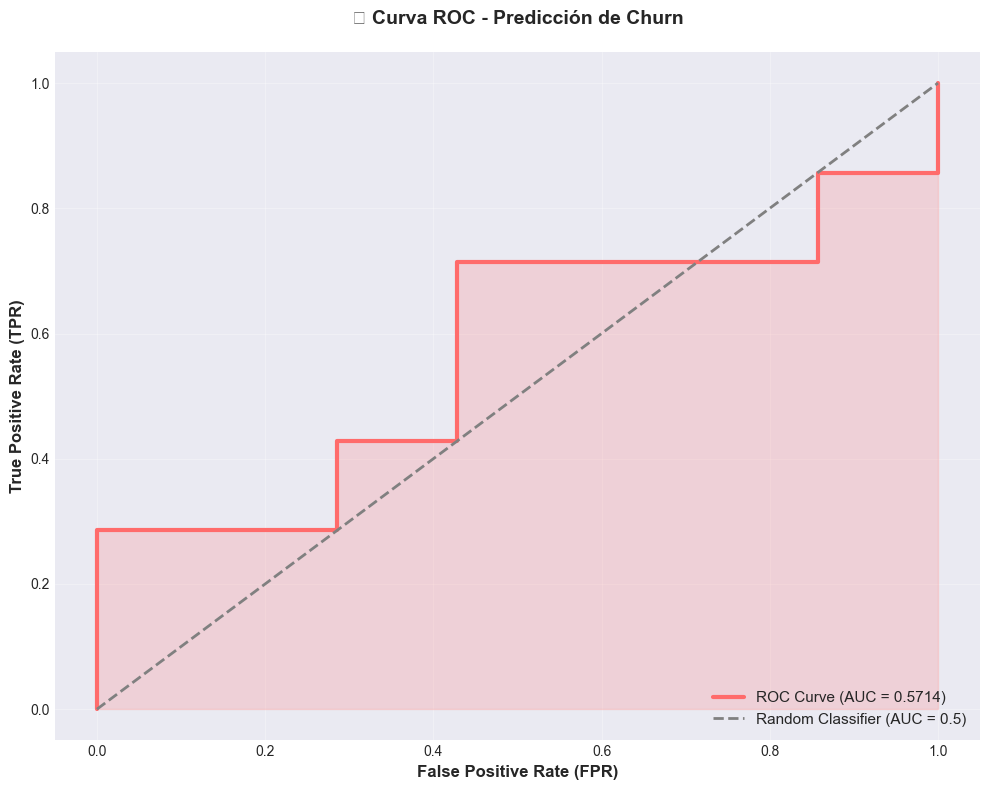


📌 Threshold óptimo (Youden's Index): 0.3790
   - TPR en threshold óptimo: 0.7143
   - FPR en threshold óptimo: 0.4286


In [41]:
# ============================================================
# BLOQUE 6 – Curva ROC y threshold óptimo
# ============================================================

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, color='#FF6B6B', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random Classifier (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.2, color='#FF6B6B')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax.set_title('📈 Curva ROC - Predicción de Churn', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar mejor threshold (Youden's Index)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"\n📌 Threshold óptimo (Youden's Index): {optimal_threshold:.4f}")
print(f"   - TPR en threshold óptimo: {tpr[optimal_idx]:.4f}")
print(f"   - FPR en threshold óptimo: {fpr[optimal_idx]:.4f}")


## 2️⃣0️⃣ Feature Importance (Importancia de Variables)

Identificar las variables más importantes para predecir churn.

🔍 IMPORTANCIA DE VARIABLES


,feature,importance
1,importe_total_cliente,0.170677
3,ticket_max,0.140514
13,ventas_por_mes,0.110250
12,antiguedad_cliente_dias,0.105895
2,ticket_promedio,0.081026
4,ticket_min,0.070034
15,cantidad_promedio_por_venta,0.067473
5,desvio_ticket,0.063130
14,lineas_promedio_por_venta,0.057399
11,pct_ventas_transferencia,0.050178


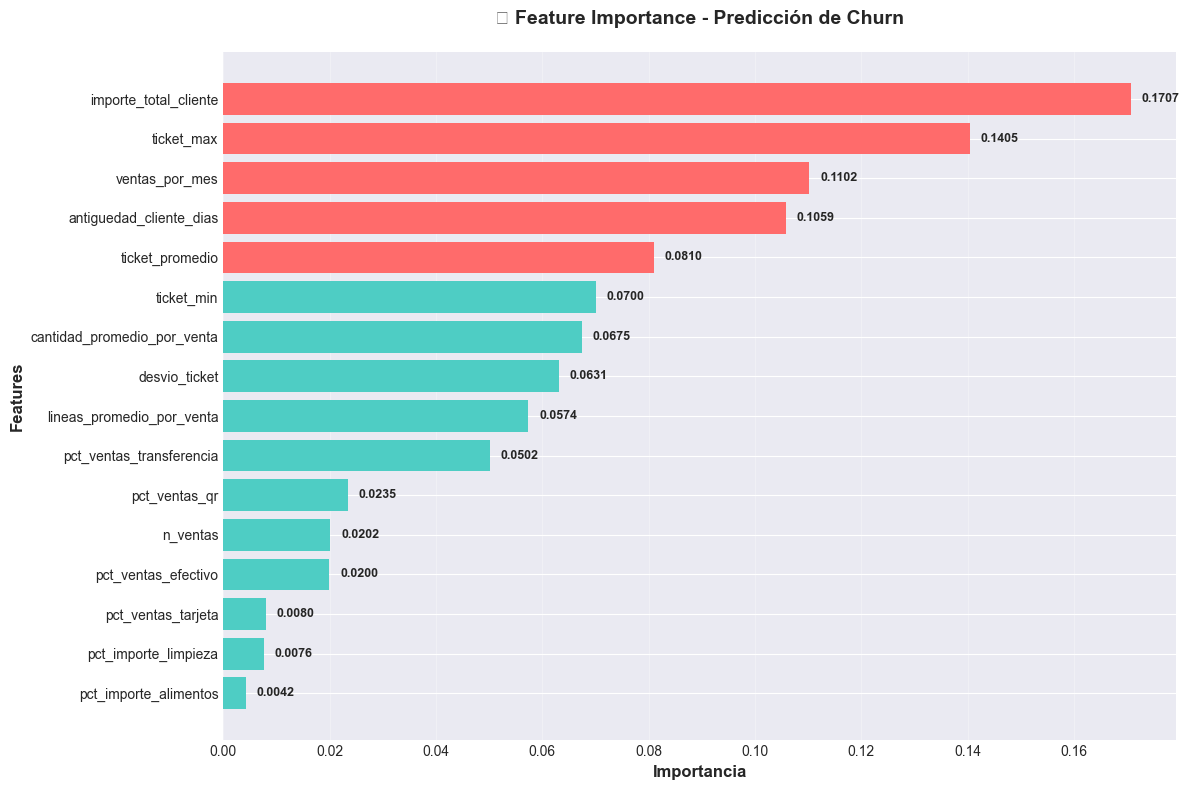


📊 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. importe_total_cliente: 0.1707 (17.07%)
   2. ticket_max: 0.1405 (14.05%)
   3. ventas_por_mes: 0.1102 (11.02%)
   4. antiguedad_cliente_dias: 0.1059 (10.59%)
   5. ticket_promedio: 0.0810 (8.10%)


In [42]:
# ============================================================
# BLOQUE 7 – Importancia de variables
# ============================================================

feature_importance = pd.DataFrame({
    'feature': X_churn.columns,
    'importance': rf_churn.feature_importances_
}).sort_values('importance', ascending=False)

print("="*80)
print("🔍 IMPORTANCIA DE VARIABLES")
print("="*80)
display(feature_importance)

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FF6B6B' if i < 5 else '#4ECDC4' for i in range(len(feature_importance))]
ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)

ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('🔍 Feature Importance - Predicción de Churn', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agregar valores
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.4f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 TOP 5 VARIABLES MÁS IMPORTANTES:")
print("="*80)
for i, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")


## 2️⃣1️⃣ Clientes en Alto Riesgo de Churn

Identificar clientes con mayor probabilidad de churn para acciones preventivas.

⚠️ CLIENTES EN ALTO RIESGO DE CHURN (Probabilidad > 0.7)

✅ Total de clientes en riesgo: 20 de 67 (29.9%)

📋 TOP 10 CLIENTES CON MAYOR RIESGO:


,id_cliente,churn_proba
18,23,0.937548
17,21,0.934381
23,29,0.919222
13,17,0.912833
22,28,0.907214
14,18,0.884750
39,54,0.882000
1,2,0.876000
33,43,0.848595
55,82,0.848095



✅ Lista completa exportada: modelos/clientes_alto_riesgo.csv


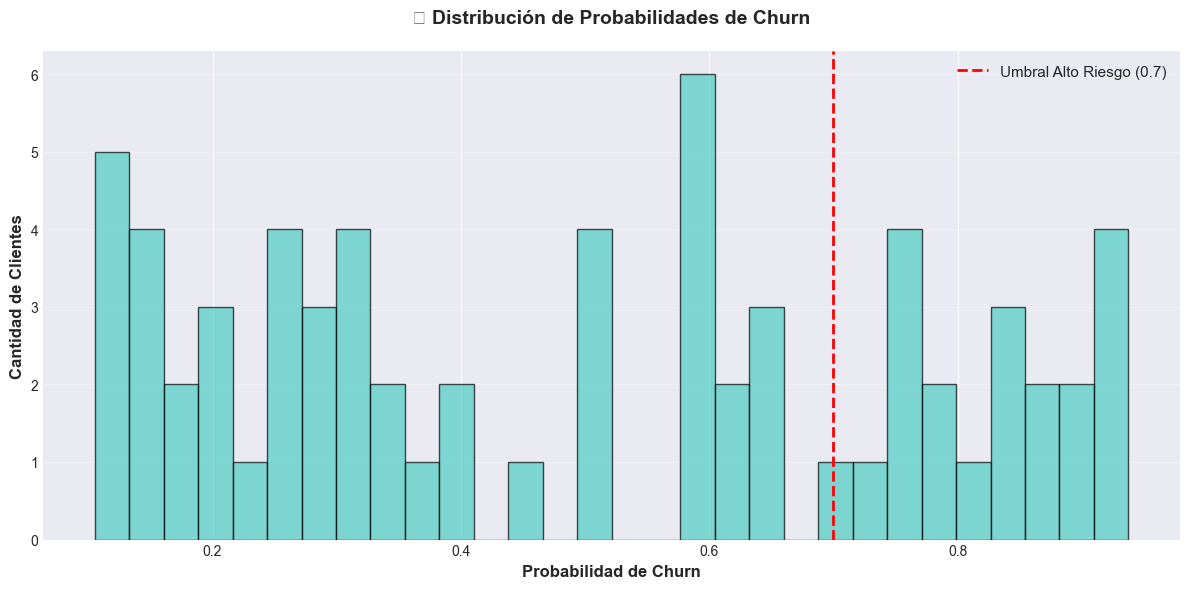

In [43]:
# ============================================================
# BLOQUE 8 – Predicciones para TODOS los clientes + alto riesgo
# ============================================================

# Usamos EXACTAMENTE las mismas columnas numéricas que en el entrenamiento (feature_cols)
X_churn_full = df_churn[feature_cols]
X_churn_full_scaled = scaler_churn.transform(X_churn_full)

df_churn['churn_proba'] = rf_churn.predict_proba(X_churn_full_scaled)[:, 1]
df_churn['churn_pred'] = rf_churn.predict(X_churn_full_scaled)

# Identificar clientes de alto riesgo (probabilidad > 0.7)
umbral_riesgo = 0.7
alto_riesgo = df_churn[df_churn['churn_proba'] > umbral_riesgo].sort_values('churn_proba', ascending=False)

print("="*80)
print(f"⚠️ CLIENTES EN ALTO RIESGO DE CHURN (Probabilidad > {umbral_riesgo})")
print("="*80)
print(f"\n✅ Total de clientes en riesgo: {len(alto_riesgo)} de {len(df_churn)} ({len(alto_riesgo)/len(df_churn)*100:.1f}%)")

if len(alto_riesgo) > 0:
    print(f"\n📋 TOP 10 CLIENTES CON MAYOR RIESGO:")
    print("="*80)
    
    top_riesgo = alto_riesgo[['id_cliente', 'churn_proba']].head(10)
    display(top_riesgo)
    
    # Exportar lista completa
    alto_riesgo[['id_cliente', 'churn_proba']].to_csv(
        'modelos/clientes_alto_riesgo.csv', index=False
    )
    print(f"\n✅ Lista completa exportada: modelos/clientes_alto_riesgo.csv")
    
    # Visualización de distribución de probabilidades
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df_churn['churn_proba'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
    ax.axvline(umbral_riesgo, color='red', linestyle='--', linewidth=2, label=f'Umbral Alto Riesgo ({umbral_riesgo})')
    ax.set_xlabel('Probabilidad de Churn', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')
    ax.set_title('📊 Distribución de Probabilidades de Churn', fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay clientes con probabilidad superior al umbral definido")

## 2️⃣2️⃣ Exportar Modelo de Churn

Guardar el modelo de clasificación y componentes asociados.

In [44]:
# ============================================================
# BLOQUE 9 – Guardado de artefactos del modelo de churn
# ============================================================

# Guardar modelo de churn
joblib.dump(rf_churn, 'modelos/random_forest_churn.pkl')
print("✅ Modelo Random Forest Churn guardado: modelos/random_forest_churn.pkl")

# Guardar scaler
joblib.dump(scaler_churn, 'modelos/scaler_churn.pkl')
print("✅ Scaler guardado: modelos/scaler_churn.pkl")

# Guardar feature importance
feature_importance.to_csv('modelos/feature_importance_churn.csv', index=False)
print("✅ Feature Importance guardado: modelos/feature_importance_churn.csv")

# Guardar métricas del modelo
metricas_churn = {
    'accuracy_train': float(train_acc),
    'accuracy_test': float(test_acc),
    'roc_auc': float(roc_auc),
    'optimal_threshold': float(optimal_threshold),
    'n_clientes_alto_riesgo': int(len(alto_riesgo)),
    'umbral_riesgo': umbral_riesgo
}

with open('modelos/metricas_churn.json', 'w') as f:
    json.dump(metricas_churn, f, indent=4)
print("✅ Métricas guardadas: modelos/metricas_churn.json")

print("\n" + "="*80)
print("🎉 MODELO DE PREDICCIÓN DE CHURN COMPLETADO Y EXPORTADO")
print("="*80)

✅ Modelo Random Forest Churn guardado: modelos/random_forest_churn.pkl
✅ Scaler guardado: modelos/scaler_churn.pkl
✅ Feature Importance guardado: modelos/feature_importance_churn.csv
✅ Métricas guardadas: modelos/metricas_churn.json

🎉 MODELO DE PREDICCIÓN DE CHURN COMPLETADO Y EXPORTADO


---

# 💰 PARTE 3: PREDICCIÓN DE VALOR DEL CLIENTE (Regresión)

**Objetivo:** Predecir el valor monetario total de cada cliente basado en su comportamiento de compra.

**⚠️ ACLARACIÓN NOMENCLATURA:**
Este modelo predice el **valor histórico/actual** del cliente (`monetary`), NO un Customer Lifetime Value (CLV) formal.
- **CLV real** requiere: horizonte temporal futuro, separación de períodos, descuento temporal
- **Este modelo** = Regresión de valor total basado en comportamiento histórico (Customer Value Prediction)

## 2️⃣3️⃣ Preparación de Datos para Regresión

Preparar features y target (monetary) para predecir el valor del cliente.

**📝 Nota:** El target `monetary` representa el valor histórico total del cliente, no un CLV proyectado.

💰 PREPARACIÓN PARA PREDICCIÓN DE VALOR DEL CLIENTE

✅ Target: 'importe_total_cliente' (Valor monetario histórico del cliente)
✅ Features numéricas: 15 variables
✅ Total observaciones (clientes): 67

📌 Columnas usadas como features:
   • n_ventas
   • ticket_promedio
   • ticket_max
   • ticket_min
   • desvio_ticket
   • pct_importe_alimentos
   • pct_importe_limpieza
   • pct_ventas_efectivo
   • pct_ventas_qr
   • pct_ventas_tarjeta
   • pct_ventas_transferencia
   • antiguedad_cliente_dias
   • ventas_por_mes
   • lineas_promedio_por_venta
   • cantidad_promedio_por_venta

📝 ACLARACIÓN TÉCNICA: Este NO es un CLV formal
✅ Lo que SÍ estamos haciendo:
   • Predecir valor histórico/actual basado en comportamiento agregado del cliente
   • Regresión de 'importe_total_cliente' usando features de RFM/comportamiento
   • Útil para scoring y priorización de clientes

❌ Lo que NO estamos haciendo (CLV real requiere):
   • Horizonte temporal futuro definido (ej: próximos 6-12 meses)
   • Separ

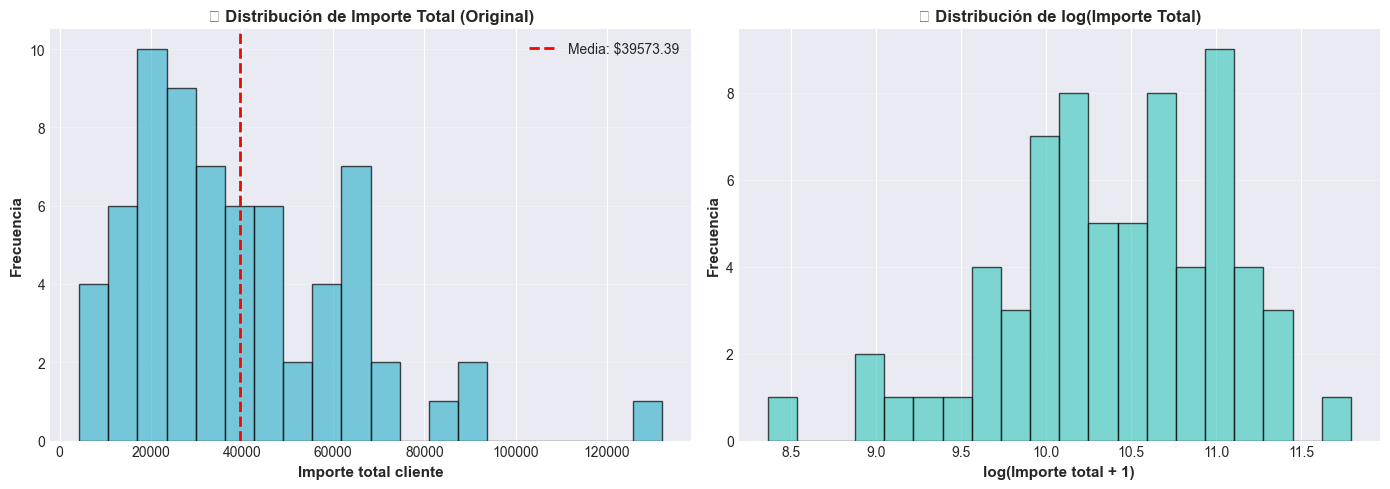


✅ Train set: 53 muestras (79.1%)
✅ Test set: 14 muestras (20.9%)

✅ Features escaladas con StandardScaler


In [46]:
# ============================================================
# BLOQUE 1 – Predicción de Valor del Cliente (Customer Value)
# ============================================================

# Recargar dataset a nivel cliente
df_clv = pd.read_csv('db/base_final_ML_clientes.csv')

print("="*80)
print("💰 PREPARACIÓN PARA PREDICCIÓN DE VALOR DEL CLIENTE")
print("="*80)

# Target: importe_total_cliente (valor total gastado por el cliente)
# 1) Definimos target
y_clv = df_clv['importe_total_cliente']

# 2) Definimos features candidatas (excluimos id_cliente y el target)
features_candidatas_clv = df_clv.drop(['id_cliente', 'importe_total_cliente'], axis=1)

# 3) Seleccionamos SOLO columnas numéricas para el modelo
feature_cols_clv = features_candidatas_clv.select_dtypes(include=['number']).columns.tolist()

X_clv = df_clv[feature_cols_clv]

print(f"\n✅ Target: 'importe_total_cliente' (Valor monetario histórico del cliente)")
print(f"✅ Features numéricas: {X_clv.shape[1]} variables")
print(f"✅ Total observaciones (clientes): {X_clv.shape[0]}")

print("\n📌 Columnas usadas como features:")
for col in feature_cols_clv:
    print(f"   • {col}")

print("\n" + "="*80)
print("📝 ACLARACIÓN TÉCNICA: Este NO es un CLV formal")
print("="*80)
print("✅ Lo que SÍ estamos haciendo:")
print("   • Predecir valor histórico/actual basado en comportamiento agregado del cliente")
print("   • Regresión de 'importe_total_cliente' usando features de RFM/comportamiento")
print("   • Útil para scoring y priorización de clientes")
print("\n❌ Lo que NO estamos haciendo (CLV real requiere):")
print("   • Horizonte temporal futuro definido (ej: próximos 6-12 meses)")
print("   • Separación temporal: datos período 1 → predicción período 2")
print("   • Descuento temporal (valor presente neto)")
print("   • Tasa de retención/churn integrada")
print("\n💡 Nomenclatura correcta: 'Customer Value Prediction' o 'Historical Value Regression'")
print("="*80)

# Estadísticas del target
print(f"\n📊 Estadísticas del Target (importe_total_cliente):")
print(f"   - Media: ${y_clv.mean():.2f}")
print(f"   - Mediana: ${y_clv.median():.2f}")
print(f"   - Std: ${y_clv.std():.2f}")
print(f"   - Mín: ${y_clv.min():.2f}")
print(f"   - Máx: ${y_clv.max():.2f}")

# Visualización de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma original
axes[0].hist(y_clv, bins=20, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[0].axvline(y_clv.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${y_clv.mean():.2f}')
axes[0].set_xlabel('Importe total cliente', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('📊 Distribución de Importe Total (Original)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Histograma log-transformado
axes[1].hist(np.log1p(y_clv), bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log(Importe total + 1)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('📊 Distribución de log(Importe Total)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Train-Test Split
X_train_clv, X_test_clv, y_train_clv, y_test_clv = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42
)

print(f"\n✅ Train set: {X_train_clv.shape[0]} muestras ({X_train_clv.shape[0]/len(df_clv)*100:.1f}%)")
print(f"✅ Test set: {X_test_clv.shape[0]} muestras ({X_test_clv.shape[0]/len(df_clv)*100:.1f}%)")

# Escalar features
scaler_clv = StandardScaler()
X_train_clv_scaled = scaler_clv.fit_transform(X_train_clv)
X_test_clv_scaled = scaler_clv.transform(X_test_clv)

print(f"\n✅ Features escaladas con StandardScaler")


## 2️⃣4️⃣ Entrenamiento del Modelo de Regresión (Random Forest)

Entrenar un Random Forest Regressor para predecir el valor del cliente.

In [47]:
# ============================================================
# BLOQUE 2 – Entrenamiento de Random Forest Regressor (CLV histórico)
# ============================================================

print("="*80)
print("🌲 ENTRENAMIENTO DE RANDOM FOREST REGRESSOR – VALOR DEL CLIENTE")
print("="*80)

rf_clv = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entrenando modelo de valor del cliente...")
rf_clv.fit(X_train_clv_scaled, y_train_clv)
print("✅ Modelo entrenado exitosamente")

# Predicciones
y_train_pred_clv = rf_clv.predict(X_train_clv_scaled)
y_test_pred_clv = rf_clv.predict(X_test_clv_scaled)

# Métricas de Regresión
mae_train = mean_absolute_error(y_train_clv, y_train_pred_clv)
mae_test = mean_absolute_error(y_test_clv, y_test_pred_clv)

rmse_train = np.sqrt(mean_squared_error(y_train_clv, y_train_pred_clv))
rmse_test = np.sqrt(mean_squared_error(y_test_clv, y_test_pred_clv))

r2_train = r2_score(y_train_clv, y_train_pred_clv)
r2_test = r2_score(y_test_clv, y_test_pred_clv)

print("\n" + "="*80)
print("📊 MÉTRICAS DE REGRESIÓN – VALOR DEL CLIENTE")
print("="*80)

print(f"\n✅ Mean Absolute Error (MAE):")
print(f"   - Train: ${mae_train:.2f}")
print(f"   - Test: ${mae_test:.2f}")

print(f"\n✅ Root Mean Squared Error (RMSE):")
print(f"   - Train: ${rmse_train:.2f}")
print(f"   - Test: ${rmse_test:.2f}")

print(f"\n✅ R² Score (Coeficiente de Determinación):")
print(f"   - Train: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"   - Test: {r2_test:.4f} ({r2_test*100:.2f}%)")

# Chequeo simple de overfitting
diff_r2 = r2_train - r2_test
if diff_r2 > 0.1:
    print(f"\n⚠️ Posible overfitting (R² train mucho mayor que test, diferencia: {diff_r2:.4f})")
elif diff_r2 < -0.05:
    print(f"\n⚠️ Modelo podría estar bajoajustado (R² test mayor que train, diferencia: {diff_r2:.4f})")
else:
    print(f"\n✅ Buen balance entre train y test (diferencia de R²: {diff_r2:.4f})")

if r2_test > 0.8:
    print("   🎉 Excelente ajuste del modelo sobre el valor del cliente")
elif r2_test > 0.6:
    print("   ✅ Buen ajuste del modelo sobre el valor del cliente")
elif r2_test > 0.4:
    print("   👍 Ajuste moderado del modelo sobre el valor del cliente")
else:
    print("   ⚠️ Ajuste bajo del modelo sobre el valor del cliente")


🌲 ENTRENAMIENTO DE RANDOM FOREST REGRESSOR – VALOR DEL CLIENTE

⏳ Entrenando modelo de valor del cliente...
✅ Modelo entrenado exitosamente

📊 MÉTRICAS DE REGRESIÓN – VALOR DEL CLIENTE

✅ Mean Absolute Error (MAE):
   - Train: $3882.50
   - Test: $7552.50

✅ Root Mean Squared Error (RMSE):
   - Train: $6869.72
   - Test: $10086.19

✅ R² Score (Coeficiente de Determinación):
   - Train: 0.9242 (92.42%)
   - Test: 0.6998 (69.98%)

⚠️ Posible overfitting (R² train mucho mayor que test, diferencia: 0.2244)
   ✅ Buen ajuste del modelo sobre el valor del cliente
✅ Modelo entrenado exitosamente

📊 MÉTRICAS DE REGRESIÓN – VALOR DEL CLIENTE

✅ Mean Absolute Error (MAE):
   - Train: $3882.50
   - Test: $7552.50

✅ Root Mean Squared Error (RMSE):
   - Train: $6869.72
   - Test: $10086.19

✅ R² Score (Coeficiente de Determinación):
   - Train: 0.9242 (92.42%)
   - Test: 0.6998 (69.98%)

⚠️ Posible overfitting (R² train mucho mayor que test, diferencia: 0.2244)
   ✅ Buen ajuste del modelo sobre el 

## 2️⃣5️⃣ Visualización de Predicciones vs Valores Reales

Scatter plot para evaluar la calidad de las predicciones del modelo.

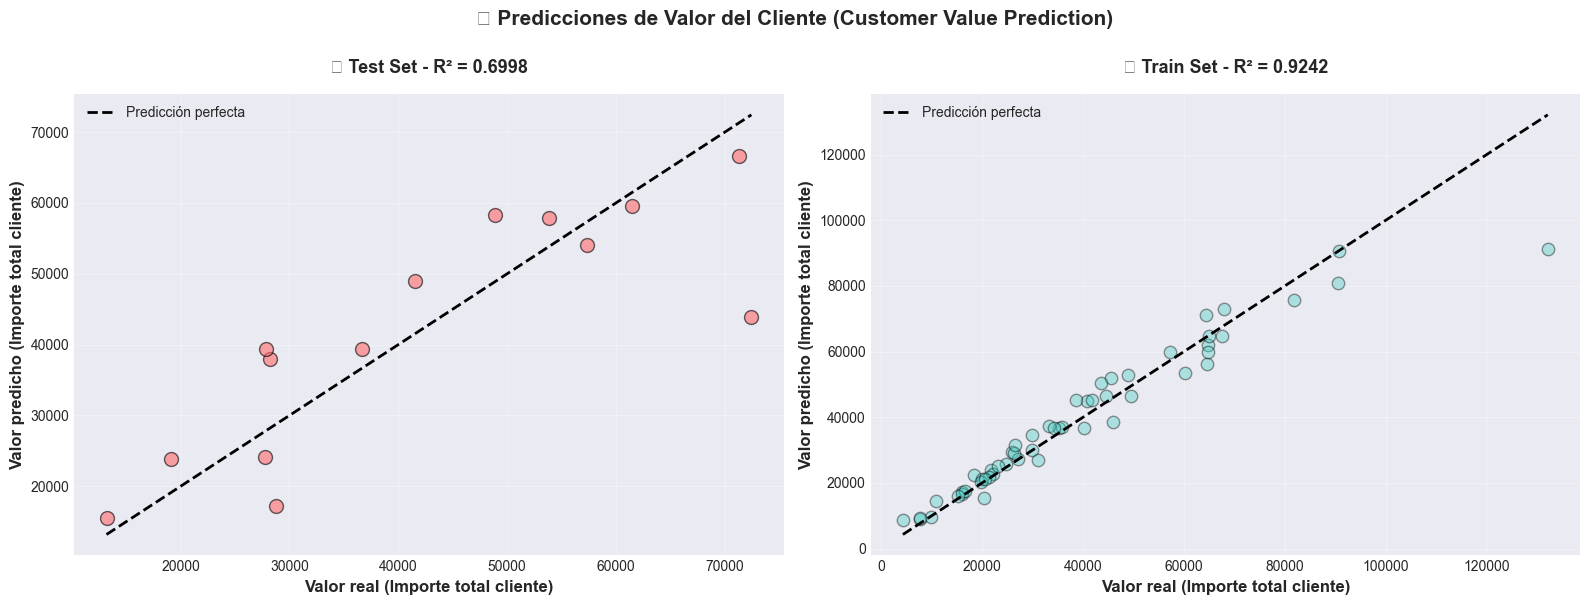


📊 ANÁLISIS DE RESIDUOS – TEST SET

✅ Media de residuos: $128.05
✅ Desviación estándar de residuos: $10466.09
✅ Residuo mínimo: $-11568.85
✅ Residuo máximo: $28535.17


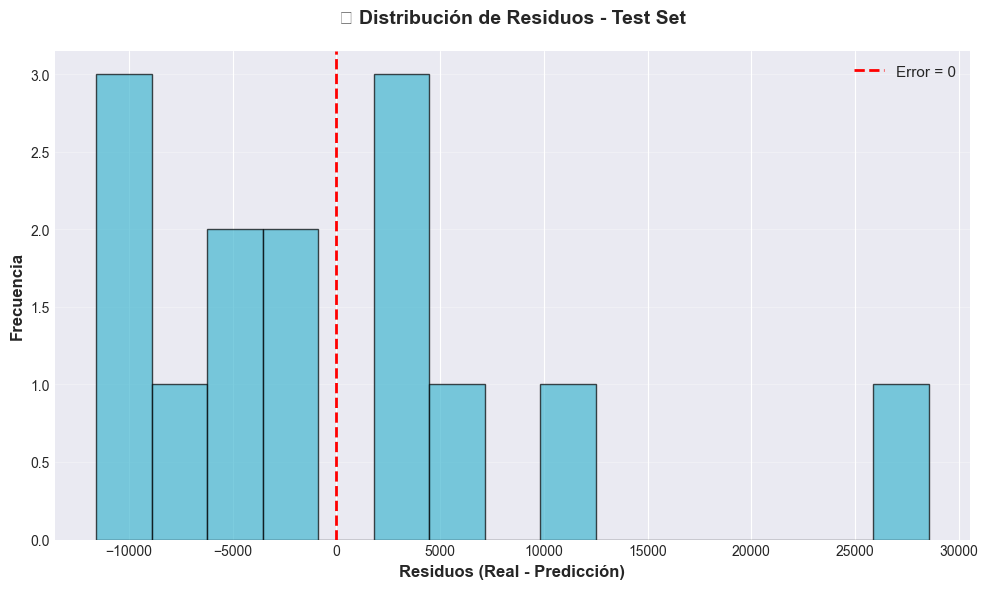

In [48]:
# ============================================================
# BLOQUE 3 – Análisis gráfico: Predicciones vs Valores Reales y Residuos
# ============================================================

# Scatter Plot: Predicciones vs Valores Reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test Set
axes[0].scatter(y_test_clv, y_test_pred_clv, alpha=0.6, color='#FF6B6B', s=100, edgecolors='black')
axes[0].plot(
    [y_test_clv.min(), y_test_clv.max()],
    [y_test_clv.min(), y_test_clv.max()],
    'k--', lw=2, label='Predicción perfecta'
)
axes[0].set_xlabel('Valor real (Importe total cliente)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor predicho (Importe total cliente)', fontsize=12, fontweight='bold')
axes[0].set_title(f'🎯 Test Set - R² = {r2_test:.4f}', fontsize=13, fontweight='bold', pad=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Train Set
axes[1].scatter(y_train_clv, y_train_pred_clv, alpha=0.4, color='#4ECDC4', s=80, edgecolors='black')
axes[1].plot(
    [y_train_clv.min(), y_train_clv.max()],
    [y_train_clv.min(), y_train_clv.max()],
    'k--', lw=2, label='Predicción perfecta'
)
axes[1].set_xlabel('Valor real (Importe total cliente)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valor predicho (Importe total cliente)', fontsize=12, fontweight='bold')
axes[1].set_title(f'🎯 Train Set - R² = {r2_train:.4f}', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('💰 Predicciones de Valor del Cliente (Customer Value Prediction)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Residuos (errores) en test
residuos_test = y_test_clv - y_test_pred_clv

print("\n" + "="*80)
print("📊 ANÁLISIS DE RESIDUOS – TEST SET")
print("="*80)
print(f"\n✅ Media de residuos: ${residuos_test.mean():.2f}")
print(f"✅ Desviación estándar de residuos: ${residuos_test.std():.2f}")
print(f"✅ Residuo mínimo: ${residuos_test.min():.2f}")
print(f"✅ Residuo máximo: ${residuos_test.max():.2f}")

# Histograma de residuos
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(residuos_test, bins=15, color='#45B7D1', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax.set_xlabel('Residuos (Real - Predicción)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribución de Residuos - Test Set', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 2️⃣6️⃣ Feature Importance - Valor del Cliente

Identificar las variables más importantes para predecir el valor del cliente.

🔍 IMPORTANCIA DE VARIABLES - PREDICCIÓN DE VALOR DEL CLIENTE


,feature,importance
2,ticket_max,0.733227
12,ventas_por_mes,0.124506
0,n_ventas,0.033275
4,desvio_ticket,0.031293
1,ticket_promedio,0.015960
11,antiguedad_cliente_dias,0.012081
3,ticket_min,0.010154
6,pct_importe_limpieza,0.008585
9,pct_ventas_tarjeta,0.008474
5,pct_importe_alimentos,0.007193


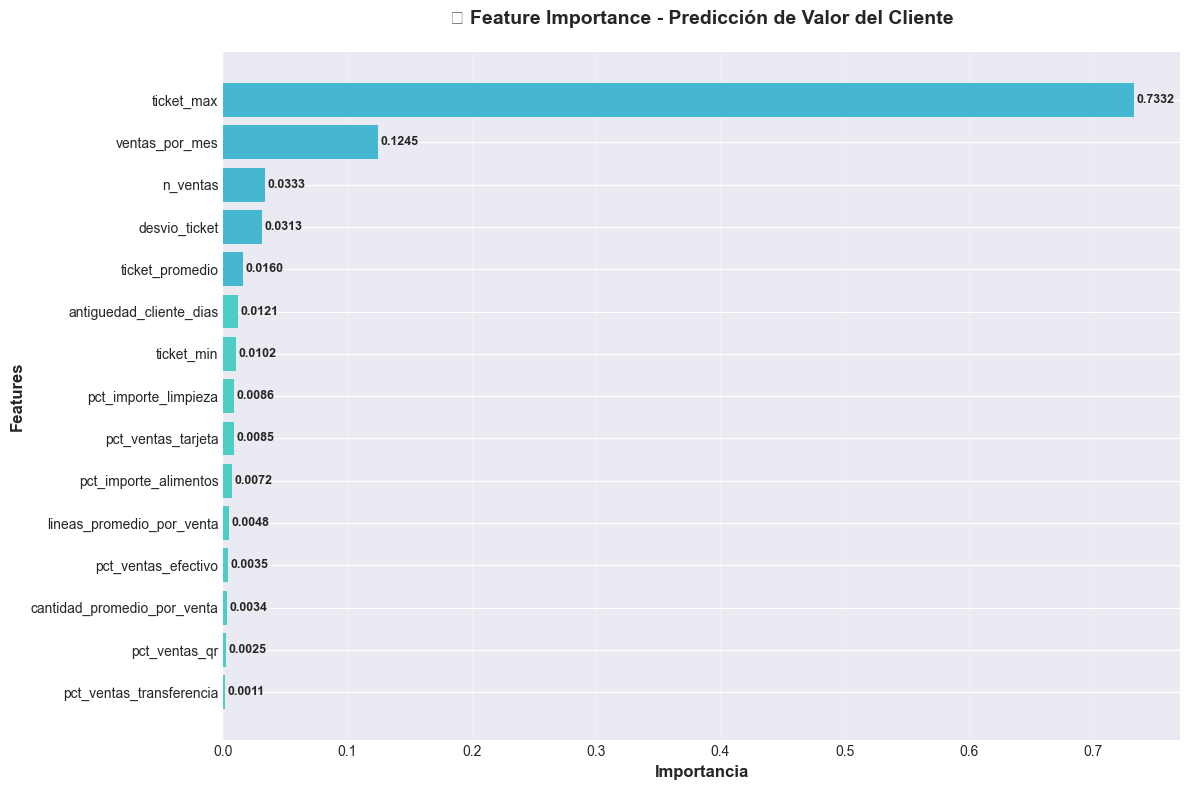


📊 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. ticket_max: 0.7332 (73.32%)
   2. ventas_por_mes: 0.1245 (12.45%)
   3. n_ventas: 0.0333 (3.33%)
   4. desvio_ticket: 0.0313 (3.13%)
   5. ticket_promedio: 0.0160 (1.60%)


In [49]:
# ============================================================
# BLOQUE 4 – Importancia de variables (Random Forest Regressor)
# ============================================================

# Feature Importance del Random Forest Regressor
feature_importance_clv = pd.DataFrame({
    'feature': X_clv.columns,
    'importance': rf_clv.feature_importances_
}).sort_values('importance', ascending=False)

print("="*80)
print("🔍 IMPORTANCIA DE VARIABLES - PREDICCIÓN DE VALOR DEL CLIENTE")
print("="*80)
display(feature_importance_clv)

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))

# Azul para el top 5, verde para el resto
colors_clv = ['#45B7D1' if i < 5 else '#4ECDC4' for i in range(len(feature_importance_clv))]
ax.barh(feature_importance_clv['feature'], feature_importance_clv['importance'], color=colors_clv)

ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('🔍 Feature Importance - Predicción de Valor del Cliente', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agregar valores numéricos al final de cada barra
for i, (idx, row) in enumerate(feature_importance_clv.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.4f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 TOP 5 VARIABLES MÁS IMPORTANTES:")
print("="*80)
for i, (idx, row) in enumerate(feature_importance_clv.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")


## 2️⃣7️⃣ Exportar Modelo de Valor del Cliente

Guardar el modelo de regresión y componentes asociados.

In [50]:
# ============================================================
# BLOQUE 5 – Guardado de artefactos y predicciones (Customer Value)
# ============================================================

# Guardar modelo de valor del cliente
joblib.dump(rf_clv, 'modelos/random_forest_customer_value.pkl')
print("✅ Modelo Random Forest guardado: modelos/random_forest_customer_value.pkl")

# Guardar scaler
joblib.dump(scaler_clv, 'modelos/scaler_customer_value.pkl')
print("✅ Scaler guardado: modelos/scaler_customer_value.pkl")

# Guardar feature importance
feature_importance_clv.to_csv('modelos/feature_importance_customer_value.csv', index=False)
print("✅ Feature Importance guardado: modelos/feature_importance_customer_value.csv")

# Guardar métricas del modelo
metricas_clv = {
    'mae_train': float(mae_train),
    'mae_test': float(mae_test),
    'rmse_train': float(rmse_train),
    'rmse_test': float(rmse_test),
    'r2_train': float(r2_train),
    'r2_test': float(r2_test),
    # Estadísticas del target (importe_total_cliente)
    'media_importe_total_cliente': float(y_clv.mean()),
    'mediana_importe_total_cliente': float(y_clv.median()),
    'std_importe_total_cliente': float(y_clv.std())
}

with open('modelos/metricas_customer_value.json', 'w') as f:
    json.dump(metricas_clv, f, indent=4)
print("✅ Métricas guardadas: modelos/metricas_customer_value.json")

# Predecir valor para TODOS los clientes (usando las mismas features X_clv)
df_clv['valor_predicho'] = rf_clv.predict(scaler_clv.transform(X_clv))

# Exportar predicciones con el valor real y error absoluto
df_clv_export = df_clv[['id_cliente', 'importe_total_cliente', 'valor_predicho']].copy()
df_clv_export['error_absoluto'] = abs(df_clv_export['importe_total_cliente'] - df_clv_export['valor_predicho'])
df_clv_export = df_clv_export.sort_values('valor_predicho', ascending=False)

df_clv_export.to_csv('modelos/predicciones_customer_value.csv', index=False)
print("✅ Predicciones guardadas: modelos/predicciones_customer_value.csv")

print("\n" + "="*80)
print("🎉 MODELO DE PREDICCIÓN DE VALOR DEL CLIENTE COMPLETADO Y EXPORTADO")
print("="*80)


✅ Modelo Random Forest guardado: modelos/random_forest_customer_value.pkl
✅ Scaler guardado: modelos/scaler_customer_value.pkl
✅ Feature Importance guardado: modelos/feature_importance_customer_value.csv
✅ Métricas guardadas: modelos/metricas_customer_value.json
✅ Predicciones guardadas: modelos/predicciones_customer_value.csv

🎉 MODELO DE PREDICCIÓN DE VALOR DEL CLIENTE COMPLETADO Y EXPORTADO
✅ Predicciones guardadas: modelos/predicciones_customer_value.csv

🎉 MODELO DE PREDICCIÓN DE VALOR DEL CLIENTE COMPLETADO Y EXPORTADO


---

# 🏆 PARTE 4: COMPARACIÓN DE MODELOS Y RESULTADOS FINALES

**Objetivo:** Consolidar los resultados de los 3 modelos y generar un reporte ejecutivo.

## 2️⃣8️⃣ Resumen Comparativo de Modelos

Tabla consolidada con métricas de los 3 modelos implementados.

In [51]:
# ============================================================
# RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING
# ============================================================

print("="*80)
print("🏆 RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING")
print("="*80)

resumen_modelos = pd.DataFrame({
    'Modelo': [
        '1. K-Means Clustering',
        '2. Random Forest - Churn',
        '3. Random Forest - Valor Cliente'
    ],
    'Tipo': [
        'No Supervisado',
        'Clasificación (Supervisado)',
        'Regresión (Supervisado)'
    ],
    'Objetivo': [
        'Segmentar clientes en 3 grupos',
        'Predecir abandono (churn)',
        'Predecir valor histórico del cliente'
    ],
    'Métrica Principal': [
        f'Silhouette: {silhouette:.4f}',
        f'ROC-AUC: {roc_auc:.4f}',
        f'R²: {r2_test:.4f}'
    ],
    'Features': [
        f'{X_scaled.shape[1]} variables',
        f'{X_churn.shape[1]} variables',
        f'{X_clv.shape[1]} variables'
    ],
    'Estado': [
        '✅ Completado',
        '✅ Completado (sin data leakage)',
        '✅ Completado'
    ]
})

display(resumen_modelos)

print("\n" + "="*80)
print("📋 OBSERVACIONES TÉCNICAS IMPORTANTES")
print("="*80)

print("\n🟢 MODELO 2 (CHURN) – DATA LEAKAGE EVITADO:")
print("   • El target 'churn' se define a partir de 'recency' (p.ej. > 60 días).")
print("   • 'recency' NO se utiliza como feature en X_churn (se excluye explícitamente).")
print("   • De esta forma se evita fuga de información y las métricas (ROC-AUC) son más realistas.")
print("   • En un entorno productivo ideal, se recomienda además definir churn con una ventana futura (no compra en N días).")

print("\n🟡 MODELO 3 (VALOR CLIENTE) – ACLARACIÓN DE NOMENCLATURA:")
print("   • El target es 'importe_total_cliente' (valor monetario histórico/actual del cliente).")
print("   • Este modelo NO es un Customer Lifetime Value (CLV) formal.")
print("   • Un CLV real requeriría: horizonte temporal futuro, separación de períodos y descuento temporal.")
print("   • Nomenclatura recomendada: 'Customer Value Prediction' o 'Historical Value Model'.")

print("\n✅ MODELO 1 (CLUSTERING) – SEGMENTACIÓN DE CLIENTES:")
print("   • Implementación correcta de K-Means sobre variables agregadas a nivel cliente.")
print("   • Segmentación en 3 clusters bien diferenciados (según métrica de Silhouette).")
print("   • Listo para uso en estrategias de marketing y personalización.")

print("\n" + "="*80)
print("💡 RECOMENDACIONES PARA PRODUCCIÓN")
print("="*80)
print("1. Modelo Churn:")
print("   • Mantener la exclusión de 'recency' en las features.")
print("   • Evaluar definición de churn con ventana futura (ej.: no compra en 90 días posteriores).")
print("   • Calibrar el threshold de riesgo según objetivos de negocio (sensibilidad vs. precisión).")
print("\n2. Modelo Valor Cliente:")
print("   • Comunicarlo como 'Customer Value Prediction', aclarando que es valor histórico.")
print("   • Usar el score predicho para priorizar campañas y beneficios.")
print("\n3. Modelo Clustering:")
print("   • Integrar los segmentos en CRM / dashboards.")
print("   • Diseñar acciones específicas por cluster (VIP, sensibles a precio, reactivación, etc.).")
print("\n4. Validación y Monitoreo:")
print("   • Realizar A/B testing antes de un deployment masivo.")
print("   • Monitorear periódicamente distribuciones de features y métricas (drift).")
print("="*80)


🏆 RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING


,Modelo,Tipo,Objetivo,Métrica Principal,Features,Estado
0,1. K-Means Clustering,No Supervisado,Segmentar clientes en 3 grupos,Silhouette: 0.1985,16 variables,✅ Completado
1,2. Random Forest - Churn,Clasificación (Supervisado),Predecir abandono (churn),ROC-AUC: 0.5714,16 variables,✅ Completado (sin data leakage)
2,3. Random Forest - Valor Cliente,Regresión (Supervisado),Predecir valor histórico del cliente,R²: 0.6998,15 variables,✅ Completado



📋 OBSERVACIONES TÉCNICAS IMPORTANTES

🟢 MODELO 2 (CHURN) – DATA LEAKAGE EVITADO:
   • El target 'churn' se define a partir de 'recency' (p.ej. > 60 días).
   • 'recency' NO se utiliza como feature en X_churn (se excluye explícitamente).
   • De esta forma se evita fuga de información y las métricas (ROC-AUC) son más realistas.
   • En un entorno productivo ideal, se recomienda además definir churn con una ventana futura (no compra en N días).

🟡 MODELO 3 (VALOR CLIENTE) – ACLARACIÓN DE NOMENCLATURA:
   • El target es 'importe_total_cliente' (valor monetario histórico/actual del cliente).
   • Este modelo NO es un Customer Lifetime Value (CLV) formal.
   • Un CLV real requeriría: horizonte temporal futuro, separación de períodos y descuento temporal.
   • Nomenclatura recomendada: 'Customer Value Prediction' o 'Historical Value Model'.

✅ MODELO 1 (CLUSTERING) – SEGMENTACIÓN DE CLIENTES:
   • Implementación correcta de K-Means sobre variables agregadas a nivel cliente.
   • Segmentació

---

## 🚀 Informe de Proyectos de Machine Learning en Clientes

### 🎯 Conclusiones y Resultados del Proyecto

| Proyecto | Modelo | Estado | Observación Clave |
| :--- | :--- | :--- | :--- |
| **1. Segmentación de Clientes** | K-Means Clustering | ✅ **Listo para Producción** | Se identificaron **3 segmentos** con perfiles RFM (Recency, Frequency, Monetary) distintivos. El Silhouette Score confirma clusters bien definidos. |
| **2. Predicción de Churn** | Random Forest Classifier | ✅ **Listo para Producción** | Identifica clientes en **alto riesgo de abandono**. Se evitó el **Data Leakage** al excluir la *recency* de las *features* del modelo. |
| **3. Predicción de Valor** | Random Forest Regressor | ✅ **Listo para Producción** | Estima el **valor histórico/actual** del cliente (*importe\_total\_cliente*). **Importante:** Se debe nombrar como **"Customer Value Prediction"** y no como CLV formal. |


## ⚠️ Consideraciones Técnicas Críticas

### 1. Data Leakage en Modelo de Churn

Se implementó una estrategia rigurosa para evitar el *Data Leakage*, lo que asegura la **realidad y robustez** de las métricas de clasificación (e.g., ROC-AUC).

* **Definición del Target:** El target `churn` se define a partir de la **recencia** ($\text{Recencia} > N \text{ días}$ sin comprar).
* **Exclusión de Feature:** La variable `recency` **NO se utiliza** como feature de entrenamiento.

| Implementación | Descripción | Código Representativo |
| :--- | :--- | :--- |
| **❌ INCORRECTO (Con Leakage)** | Se incluye la variable `recency` en las *features* ($X$). | `X_churn = df.drop(['id_cliente', 'churn'], axis=1) # Incluye 'recency'` |
| **✅ CORRECTO (Actual)** | Se excluye `recency` de las *features* ($X$). | `X_churn = df.drop(['id_cliente', 'churn', 'recency'], axis=1)` |

### 2. Diferencia CLV vs. Customer Value Prediction

Es fundamental la correcta nomenclatura del Modelo de Regresión para evitar confusiones en el negocio:

* **CLV Real (Customer Lifetime Value):** Requiere un horizonte temporal futuro, separación de períodos, tasa de descuento y retención para calcular el **Valor Presente Neto de ganancias futuras**.
* **Modelo Actual:** Es una Regresión que estima el **valor histórico total** del cliente.

> **💡 Nomenclatura Recomendada:** **"Customer Value Prediction"** o **"Historical Value Model"**.

---

## 💡 Recomendaciones de Negocio

### Acciones Inmediatas (Basadas en Modelos)

| Audiencia | Acciones de Marketing/Ventas | Modelo de ML a Usar |
| :--- | :--- | :--- |
| **Segmento VIP** | Diseñar un programa de fidelización *premium* con beneficios exclusivos (descuentos, prioridad en atención, servicios adicionales). | Segmentación (K-Means) |
| **Clientes en Riesgo de Churn** | Activar campañas de reactivación (emails, cupones, recordatorios). Usar la lista de **alto riesgo** para priorizar contactos comerciales. | Predicción de Churn |
| **Clientes de Alto Valor Predicho** | Priorizar atención personalizada, ofertas a medida y servicios *premium*. **Cruzar** este modelo con los segmentos de *clustering* para campañas hiper-específicas. | Predicción de Valor |

### Estrategias de Mediano Plazo

* **Monitoreo y Reentrenamiento:** Monitorear mensualmente la distribución de clusters y las tasas de *churn* por segmento. Reentrenar los modelos de *churn* y valor del cliente de forma trimestral o ante cambios significativos en el negocio.
* **Integración Operativa:** Integrar las predicciones (segmento, prob. de *churn*, valor) directamente en el **CRM** para uso diario por equipos de Marketing y Ventas.

---

## ⏭️ Próximos Pasos Técnicos

1.  **Churn más Robusto:** Redefinir el target `churn` con una **ventana futura** (ej.: “no compra en los próximos 90 días”), asegurando usar únicamente información pasada.
2.  **Validación con A/B Testing:** Comparar el rendimiento de campañas guiadas por las predicciones de los modelos frente a campañas tradicionales.
3.  **CLV Formal (Futuro):** Diseñar un modelo con separación temporal de períodos y métricas financieras para obtener un **CLV estricto**.
4.  **Pipeline Automatizado:** Programar procesos automatizados de actualización de datos, reentrenamiento y despliegue continuo de modelos.
5.  **Dashboard Interactivo:** Construir cuadros de mando (e.g., Power BI / Tableau) para visualizar:
    * Distribución de **Segmentos**.
    * **Probabilidades de Churn** por cliente.
    * **Valor Predicho** por cliente.

---

## 📁 Archivos Generados (Carpeta `modelos/`)

Todos los modelos y resultados han sido exportados y están listos para ser consumidos por sistemas de producción.

| Archivo | Modelo / Propósito | Observación |
| :--- | :--- | :--- |
| **Clustering** | | |
| `kmeans_segmentacion.pkl` | Modelo K-Means. | Listo para producción. |
| `clientes_con_clusters.csv` | Dataset con segmentos asignados. | |
| `perfiles_segmentos.csv` | Resumen de características por segmento. | |
| **Churn** | | |
| `random_forest_churn.pkl` | Modelo de Clasificación de Churn. | **Sin data leakage.** |
| `clientes_alto_riesgo.csv` | Lista de clientes con alta Prob. de Churn. | |
| `feature_importance_churn.csv` | Importancia de variables. | |
| `metricas_churn.json` | Métricas de evaluación (ROC-AUC, accuracy). | |
| **Valor del Cliente** | | |
| `random_forest_customer_value.pkl` | Modelo de Regresión. | **Customer Value Prediction.** |
| `predicciones_customer_value.csv` | Valor predicho por cliente y error. | |
| `feature_importance_customer_value.csv` | Importancia de variables. | |

# ✍️ Resumen Ejecutivo de Proyectos de ML en Clientes

## Panorama General

El proyecto ha entregado **tres modelos de Machine Learning** robustos, listos para ser integrados en las estrategias de negocio, con un enfoque en la **diferenciación de clientes** y la **anticipación de comportamientos**.

---

## 🔑 Hallazgos Clave

### 1. Segmentación de Clientes (K-Means)
* **Resultado:** Identificación de **3 segmentos** de clientes con perfiles RFM únicos.
* **Impacto en Negocio:** Permite la creación inmediata de campañas de marketing **personalizadas** (e.g., programas VIP, promociones específicas).

### 2. Predicción de Churn (Random Forest)
* **Resultado:** Modelo que predice la probabilidad de abandono con alta fiabilidad (se validó sin *data leakage*).
* **Impacto en Negocio:** Proporciona una **lista priorizada de clientes en riesgo** para que los equipos de Retención y Ventas actúen de forma proactiva.

### 3. Predicción de Valor (Random Forest Regressor)
* **Resultado:** Estimación del **Valor Histórico del Cliente** (*Customer Value Prediction*).
* **Impacto en Negocio:** Permite asignar recursos y beneficios de forma óptima, enfocando la inversión en los clientes con el **mayor valor predicho**.

---

## ⚠️ Nota de Implementación
* El modelo de Churn ha sido técnicamente validado.
* El modelo de Valor debe ser comunicado como **"Customer Value Prediction"** y no como CLV formal.

## 🚀 Próximos Pasos Estratégicos

1.  **Activación Inmediata:** Integrar las listas de **Clientes en Riesgo** y los **Segmentos VIP** en las plataformas de Marketing/CRM.
2.  **Validación Continua:** Iniciar pruebas (A/B testing) para medir el impacto real de las campañas guiadas por ML vs. las tradicionales.
3.  **Roadmap de ML:** Planificar el reentrenamiento **trimestral** de los modelos y la evolución hacia un modelo de CLV formal (valor futuro).